# Multi-context VR (MCVR): behaviour and population anchoring across learning

`harry_multi_context_vr` is a new dataset (6 mice, 5-6 daily sessions each,
combined ecephys+behaviour NWB per session) built around a task-anchoring-
relevant manipulation the rest of this collection didn't have: **within
every session, the animal alternates in ~20-trial blocks between two VR
contexts with different reward locations** -- `rz1` (the long-familiar
context) and `rz2` (introduced as novel partway through training, learned
over the following days). Unlike the COHORT12 dataset used everywhere else
in `AnchorDynamics2026/`, there's no open-field session here, so there's no
grid/non-grid cell-type identity -- every analysis below uses the full
recorded population, identified only by anatomical region (from Allen CCF
registration, already in the units table).

This notebook asks the two questions motivating the new dataset:

1. **Behaviour**: how does performance in each context evolve across
   sessions, and does `rz2` actually get learned within a few days the way
   it looked by eye during the experiment?
2. **Anchoring**: reusing the exact validated method from
   `trial_cluster_anchoring.ipynb` (trial-clustering classifier) and
   `session_validity_pc1_significance.ipynb` (PC1 + circular-shift
   significance), how does population-wide anchoring strength change across
   the learning days, and does it differ between the familiar and novel
   context?

In [1]:
import sys, os, glob, re, time
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pynapple as nap
import warnings
warnings.filterwarnings('ignore')

from spatial_manifolds.data.curation import curate_clusters

plt.rcParams['font.family'] = 'Arial'

SOURCE_PATH = '/Users/harryclark/Downloads/harry_multi_context_vr/dataset/'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'
CACHE_DIR = os.path.join(FIGPATH, 'mcvr_all_sessions')
os.makedirs(CACHE_DIR, exist_ok=True)

BS, TL = 2, 230   # cm per bin, track length -- matches mcvr_tl in anaylsis_parameters.py
MIN_SPEED = 3.0   # cm/s, "moving" threshold (no beh['moving'] epoch shipped with this dataset)

CTX1_COLOR, CTX2_COLOR = '#2ca02c', '#d62728'   # rz1 (familiar) / rz2 (novel)
ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'   # matches every other AnchorDynamics2026 notebook
TYPE_LABEL = {'b': 'cued', 'nb': 'uncued'}   # 'b'/'nb' in the raw data -- whether the reward zone itself is signaled

SESSION_FILES = sorted(glob.glob(os.path.join(SOURCE_PATH, 'sub-*', '*.nwb')))
mouse_ids = sorted(set(re.search(r'sub-(M\d+)', f).group(1) for f in SESSION_FILES))
print(f'{len(SESSION_FILES)} sessions across {len(mouse_ids)} mice')

31 sessions across 6 mice


## Canonical anchoring labels and trial table

Built on demand into `data/population_state/`, in the same form as the
linear-track VR data:

    labels_mcvr/M{mouse}D{day}.npz   per-cell labels, regions, population state,
                                     per-cell shuffle threshold, gate branch
    trial_table_mcvr.csv             one row per trial: type, CONTEXT, outcome,
                                     running speed, frac_anch, pc1

**These use the shared classifier**, `spatial_manifolds.anchoring`, not the
inline copy further down this notebook. The inline copy predates two changes —
NaN-aware smoothing, and the absolute gate that stops 2-means splitting a cell
with no anchoring at all — so anything computed with it is not comparable to the
rest of the collection. On surrogates with no anchoring the ungated classifier
returns 52% of trials anchored; the gated one returns 1%.

MCVR specifics: one combined NWB per session so there is no `clip_trials`
renumbering (trial ids are the raw `number` field); 230 cm track at 2 cm bins;
every trial carries a context (rz1 familiar / rz2 novel) as well as a type
(b cued / nb uncued). No cell-classification datasheet covers these sessions, so
the population is defined by anatomy alone — all curated ENTm cells. M22 sessions
yield labels but no population state: that probe did not reach entorhinal cortex.

In [ ]:
import sys as _sys
_FIGDIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026'
if _FIGDIR not in _sys.path:
    _sys.path.insert(0, _FIGDIR)
from build_mcvr_labels import ensure_mcvr_tables, load_mcvr_labels

MC = ensure_mcvr_tables()        # builds if absent (~30 min), else reads the cache
print(MC.groupby('context').agg(trials=('trial', 'size'),
                                hit_rate=('hit', 'mean'),
                                frac_anch=('frac_anch', 'mean')).round(3).to_string())

## Data structure

Each session is a single combined NWB (`sub-M{mouse}_ses-D{day}MCVR_ecephys+behavior.nwb`),
loaded whole with `pynapple`. The pieces used below:

- **`trials`** (`IntervalSet`, one row per trial): `number`, `type` (`b`
  cued / `nb` uncued -- whether the *reward zone itself* is signaled to
  the animal that trial, not whether the background context pattern is
  visible -- that's on every trial regardless of type, see the task
  schematic below -- directly analogous to the cue-visible/blind
  manipulation used for ground-truth validation elsewhere in this
  collection), `context` (`rz1`/`rz2`), `result` (`rewarded`/`unrewarded`),
  `performance` (`hit`/`try`/`run`/`slow`).
- **`P`**: within-trial position, 0-230cm, resets every trial.
- **`travel`**: cumulative across-session distance -- exactly the `dt`
  variable `compute_vr_tcs` uses elsewhere, which means the same
  single-call-per-session tuning-curve trick applies here even though the
  file layout is otherwise different from COHORT12 (one combined NWB per
  session here, vs. separate spikes/beh files there).
- **`S`**: running speed (cm/s) -- no `moving` epoch ships with this
  dataset, so one is built here via `S.threshold(MIN_SPEED, 'above')`.
- **`lick`**: binary, DLC-derived -- used below to confirm `rz1` and `rz2`
  really do have different reward locations.
- **`units`**: standard spikeinterface QC columns (curated the same way as
  everywhere else via `curate_clusters`) plus `brain_region` from Allen CCF
  registration -- anatomical identity is available even without an
  open-field session, just not a grid/non-grid *functional* classification.

### Task schematic: the four context x trial-type conditions

Before any results, what actually differs between conditions. Two
independent manipulations, crossed: **context** (`rz1`/`rz2` -- a
constant background wall pattern that identifies which environment this
is, always visible regardless of trial type, plus a different reward-zone
position) and **trial type** (`b` cued / `nb` uncued -- whether the
*reward zone itself* is signaled to the animal that trial, not whether
the background pattern is visible). Reward-zone positions/widths below
are not invented -- they're this notebook's own numbers (median ± IQR of
stop position on hit trials, cross-validated independently against
first-lick position in Part A and stop-position detection in Part D,
matching almost exactly both ways). One structural point worth flagging
up front since it isn't visually obvious and matters for interpreting the
speed-profile analyses later: **the track continues to a fixed extent
past the reward zone regardless of performance** -- the animal doesn't
stop the trial by reaching the reward zone, it keeps running to a fixed
per-trial distance before the next teleport.

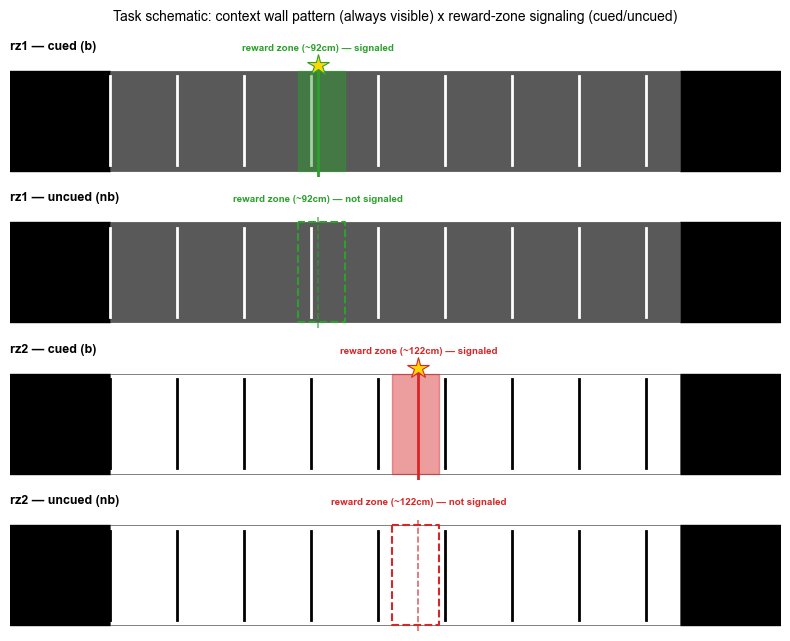

In [2]:
"""
Task schematic: the real visual structure. Black boxes bookend the
corridor at the start (0-30cm) and end (200-230cm). The corridor carries
a context-specific wall pattern -- rz1: dark grey walls (distinct from
the black boxes), a unique pattern of white spots every 20cm; rz2: white
walls, the same spot pattern in black
-- and this pattern is visible on **every** trial, cued or uncued alike:
it identifies the context, not the reward zone. What differs by trial
type is whether the reward zone itself is *signaled* -- shown here as a
bright marker at the zone on cued trials, and as a faint dashed outline
(physically present, not signaled to the animal that trial) on uncued
ones. Reward-zone position/width are this notebook's own validated
numbers (median +/- IQR of stop position on hit trials, cross-checked
against first-lick position in Part A). No axes/ticks -- this is a
schematic, not a data plot.
"""
SCHEMATIC_RZ = {
    'rz1': dict(lo=86, med=92, hi=100, color=CTX1_COLOR),
    'rz2': dict(lo=114, med=122, hi=128, color=CTX2_COLOR),
}
BOX_WIDTH = 30       # cm, black start/teleport boxes
SPOT_SPACING = 20    # cm
WALL_STYLE = {
    'rz1': dict(wall='0.35', spot='white'),   # dark grey -- distinct from the black start/teleport boxes
    'rz2': dict(wall='white', spot='black'),
}
corridor_lo, corridor_hi = BOX_WIDTH, TL - BOX_WIDTH
spot_positions = np.arange(corridor_lo, corridor_hi + 1, SPOT_SPACING)

conditions = [('rz1', 'b'), ('rz1', 'nb'), ('rz2', 'b'), ('rz2', 'nb')]
fig, axes = plt.subplots(4, 1, figsize=(8, 6.5), sharex=True)
for ax, (ctx, ttype) in zip(axes, conditions):
    rz = SCHEMATIC_RZ[ctx]
    style = WALL_STYLE[ctx]
    ax.set_xlim(0, TL)
    ax.set_ylim(0, 1)

    # black start/teleport boxes -- identical every row
    ax.fill_between([0, BOX_WIDTH], 0.05, 0.95, color='black', zorder=1, linewidth=0, edgecolor='none')
    ax.fill_between([TL - BOX_WIDTH, TL], 0.05, 0.95, color='black', zorder=1, linewidth=0, edgecolor='none')

    # context wall pattern -- always fully rendered, cued or uncued
    ax.fill_between([corridor_lo, corridor_hi], 0.05, 0.95, color=style['wall'],
                     edgecolor='0.3', linewidth=0.5, zorder=1)
    for sp in spot_positions:
        ax.axvline(sp, ymin=0.1, ymax=0.9, color=style['spot'], linewidth=2, zorder=2)

    # reward zone -- signaled (cued) vs. present-but-not-signaled (uncued)
    if ttype == 'b':
        ax.fill_between([rz['lo'], rz['hi']], 0.05, 0.95, color=rz['color'], alpha=0.45, zorder=2.5, linewidth=0, edgecolor='none')
        ax.axvline(rz['med'], color=rz['color'], linewidth=2, zorder=4)
        ax.plot(rz['med'], 1.0, marker='*', markersize=16, color='gold',
                markeredgecolor=rz['color'], markeredgewidth=0.8, zorder=5, clip_on=False)
        rz_label = f"reward zone (~{rz['med']:.0f}cm) — signaled"
    else:
        ax.fill_between([rz['lo'], rz['hi']], 0.05, 0.95, facecolor='none',
                         edgecolor=rz['color'], linestyle='--', linewidth=1.5, zorder=2.5)
        ax.axvline(rz['med'], color=rz['color'], linewidth=1.2, linestyle='--', alpha=0.7, zorder=4)
        rz_label = f"reward zone (~{rz['med']:.0f}cm) — not signaled"
    ax.text(rz['med'], 1.12, rz_label, ha='center', va='bottom',
            fontsize=7, color=rz['color'], fontweight='bold', clip_on=False)

    ax.text(0, 1.12, f'{ctx} — {TYPE_LABEL[ttype]} ({ttype})', ha='left', va='bottom', fontsize=9,
            fontweight='bold', clip_on=False)
    ax.axis('off')

fig.suptitle('Task schematic: context wall pattern (always visible) x reward-zone signaling (cued/uncued)',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_task_schematic.pdf'), dpi=200, bbox_inches='tight')
plt.show()

### Day 1: does the first-stop error change block by block?

Self-contained (loads each mouse's own day-1 session directly,
independent of the batch pipeline built later in Part A/D) since this
sits early in the notebook -- computes per-trial stop position for just
the first recorded day of each mouse, used below to check whether
stopping precision changes across the ~20-trial blocks delivered on that
first day, before the animal has had any exposure to the task at all
that session. (The all-days, per-mouse version of this -- stop position
*and* block-level hit rate, every day, not just day 1 -- comes later in
Part A once the full multi-day `speed_trial_df` exists.)

In [3]:
"""
Day-1 stop and first-lick position, every trial, all 6 mice -- computed
directly from each mouse's own day-1 NWB session (not the later batch
cache). Stop-position detection (longest contiguous low-speed run) and
first-lick position use the exact same methods as Part A/D below, just
duplicated here in self-contained form so this section doesn't depend on
anything computed later in the notebook.
"""
DAY1_SESSIONS = {'M22': 42, 'M25': 26, 'M26': 20, 'M27': 25, 'M28': 24, 'M29': 24}
STOP_SPEED_THRESH, MIN_STOP_BINS = 10.0, 2  # matches Part A's stop-position detection

def _longest_run(row, thresh):
    below = row < thresh
    best_start, best_len, cur_start, cur_len = -1, 0, -1, 0
    for i, v in enumerate(below):
        if v:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_len, best_start = cur_len, cur_start
        else:
            cur_len = 0
    return best_start, best_len

day1_rows = []
for mouse, day in DAY1_SESSIONS.items():
    path = os.path.join(SOURCE_PATH, f'sub-{mouse}', f'sub-{mouse}_ses-D{day}MCVR_ecephys+behavior.nwb')
    d1_data = nap.load_file(path)
    d1_trials = d1_data['trials'].as_dataframe().reset_index(drop=True)
    n_trials = len(d1_trials)

    tns = d1_data['trial_number']
    dt = d1_data['travel'] - (float(tns.values[0]) - 1) * TL
    n_bins_per_trial = int(TL / BS)
    S_frame = nap.TsdFrame(t=d1_data['S'].index, d=np.array(d1_data['S'].values).reshape(-1, 1))
    tc = nap.compute_1d_tuning_curves_continuous(S_frame, dt, nb_bins=n_trials * n_bins_per_trial,
                                                  minmax=[0, n_trials * TL])
    profiles = np.nan_to_num(np.array(tc)).reshape(n_trials, n_bins_per_trial)

    stop_positions = np.full(n_trials, np.nan)
    for i in range(n_trials):
        start, length = _longest_run(profiles[i], STOP_SPEED_THRESH)
        if length >= MIN_STOP_BINS:
            stop_positions[i] = (start + length / 2) * BS

    Pt, Pv = np.array(d1_data['P'].index), np.array(d1_data['P'].values)
    lt, lv = np.array(d1_data['lick'].index), np.array(d1_data['lick'].values)
    lick_positions = np.full(n_trials, np.nan)
    for i, row in d1_trials.iterrows():
        if row['performance'] != 'hit':
            continue
        m = (lt >= row['start']) & (lt < row['end']) & (lv > 0)
        if m.sum() == 0:
            continue
        pm = (Pt >= row['start']) & (Pt < row['end'])
        lick_positions[i] = np.interp(lt[m][0], Pt[pm], Pv[pm])

    for i, row in d1_trials.iterrows():
        day1_rows.append(dict(mouse=mouse, trial_i=i, context=row['context'], type=row['type'],
                               performance=row['performance'], stop_position=stop_positions[i],
                               lick_position=lick_positions[i]))

day1_df = pd.DataFrame(day1_rows).sort_values(['mouse', 'trial_i']).reset_index(drop=True)
day1_df['y_pos'] = np.arange(len(day1_df))
block_key = day1_df['mouse'] + '_' + day1_df['context']
block_id = (block_key != block_key.shift()).cumsum()
day1_block_starts = day1_df.groupby(block_id)['y_pos'].min().values
print(f'{len(day1_df)} day-1 trials across {day1_df.mouse.nunique()} mice, {len(day1_block_starts)} blocks')

1285 day-1 trials across 6 mice, 70 blocks


### Does the first-stop error change block by block within day 1?

The `M22` example above is one animal; here it's quantified across all 6
mice -- does `stop_position_error` (cm off the true reward-zone location,
same metric used throughout Part D) trend across the ~20-trial blocks
delivered on day 1, separately for each context x trial-type condition?
Aggregated to mouse x block level *first* (one point per mouse per block,
then correlated across those points) -- pooling raw trials across mice
directly risks exactly the kind of artifact already caught and fixed
elsewhere in this notebook (`Trial-execution quality metrics`, Part D).

In [4]:
"""
Block-within-context (per mouse) and stop-position error, using the
already-computed day1_df (all 6 mice, from the cell above) -- no NWB
reload needed.
"""
RZ_LOCATION = {'rz1': 92.0, 'rz2': 122.0}  # matches the validated value used throughout Part A/D
day1_df['stop_position_error'] = [
    abs(sp - RZ_LOCATION[ctx]) if pd.notna(sp) else np.nan
    for sp, ctx in zip(day1_df['stop_position'], day1_df['context'])
]

block_rows = []
for mouse, g in day1_df.groupby('mouse'):
    g = g.sort_values('trial_i').reset_index(drop=True)
    ctx_arr = g['context'].values
    block = np.zeros(len(ctx_arr), dtype=int)
    block[1:] = np.cumsum(ctx_arr[1:] != ctx_arr[:-1])
    g = g.copy()
    g['block_within_context'] = (
        pd.Series(block).groupby(pd.Series(ctx_arr)).rank(method='dense').astype(int) - 1
    ).values
    block_rows.append(g)
day1_df = pd.concat(block_rows).reset_index(drop=True)

from scipy.stats import spearmanr
day1_mouse_block = (day1_df.groupby(['mouse', 'context', 'type', 'block_within_context'])['stop_position_error']
                     .mean().reset_index())

print('corr(block_within_context, stop_position_error), mouse-block aggregated (n=6 mice):')
for ctx in ['rz1', 'rz2']:
    for ttype in ['b', 'nb']:
        sub = day1_mouse_block[(day1_mouse_block['context'] == ctx) & (day1_mouse_block['type'] == ttype)].dropna(subset=['stop_position_error'])
        r, p = spearmanr(sub['block_within_context'], sub['stop_position_error'])
        print(f'{ctx}-{TYPE_LABEL[ttype]} ({ttype}): r={r:.2f}, p={p:.3f} (n={len(sub)} mouse-block rows)')

corr(block_within_context, stop_position_error), mouse-block aggregated (n=6 mice):
rz1-cued (b): r=0.23, p=0.176 (n=37 mouse-block rows)
rz1-uncued (nb): r=0.58, p=0.000 (n=34 mouse-block rows)
rz2-cued (b): r=0.55, p=0.001 (n=32 mouse-block rows)
rz2-uncued (nb): r=0.78, p=0.000 (n=33 mouse-block rows)


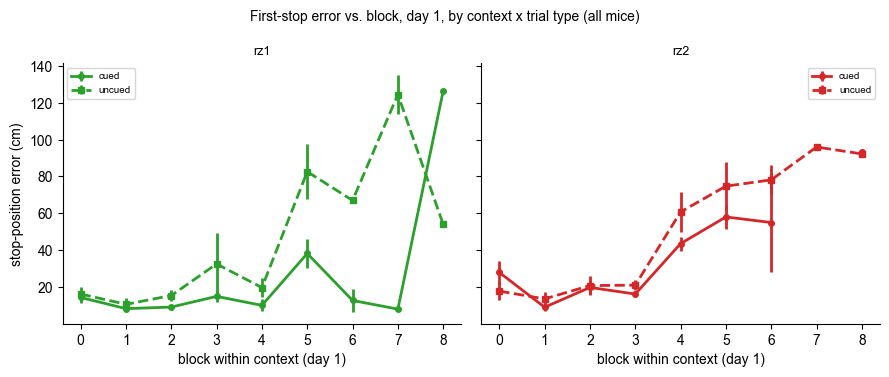

In [5]:
"""
Plot: mean +/- SEM stop-position error vs. block-within-context, all four
conditions, day 1 only, pooled across mice (mouse-block aggregated).
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = day1_mouse_block[(day1_mouse_block['context'] == ctx) & (day1_mouse_block['type'] == ttype)]
        stats = sub.groupby('block_within_context')['stop_position_error'].agg(['mean', 'sem'])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(ctx, fontsize=9)
    ax.set_xlabel('block within context (day 1)')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('stop-position error (cm)')
fig.suptitle('First-stop error vs. block, day 1, by context x trial type (all mice)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_day1_stop_error_by_block.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [6]:
"""
One example session (M22, D42) shown in full to make the structure concrete.
"""
example_mouse, example_day = 'M22', 42
example_path = os.path.join(SOURCE_PATH, f'sub-{example_mouse}',
                             f'sub-{example_mouse}_ses-D{example_day}MCVR_ecephys+behavior.nwb')
data = nap.load_file(example_path)
trials_df = data['trials'].as_dataframe()

print(f'{example_mouse} D{example_day}: {len(trials_df)} trials, '
      f'{len(data["units"])} units ({len(curate_clusters(data["units"]))} pass curation)')
print()
print('trial type (b=cued/nb=uncued):', dict(trials_df['type'].value_counts()))
print('context (rz1=familiar/rz2=novel):', dict(trials_df['context'].value_counts()))
print('performance:', dict(trials_df['performance'].value_counts()))
print()
print('brain regions (curated cells):')
print(curate_clusters(data['units']).metadata['brain_region'].value_counts())
print()
trials_df.head(8)

M22 D42: 229 trials, 293 units (190 pass curation)

trial type (b=cued/nb=uncued): {'nb': np.int64(115), 'b': np.int64(114)}
context (rz1=familiar/rz2=novel): {'rz1': np.int64(120), 'rz2': np.int64(109)}
performance: {'hit': np.int64(176), 'try': np.int64(30), 'run': np.int64(20), 'slow': np.int64(3)}

brain regions (curated cells):
brain_region
PRE      67
SUB      61
PAR      55
ENTm6     5
root      2
Name: count, dtype: int64



,start,end,number,type,context,result,performance
0,0.013702,5.604187,1,b,rz1,unrewarded,try
1,5.604197,12.620952,2,b,rz1,rewarded,hit
2,12.620962,20.304363,3,nb,rz1,rewarded,hit
3,20.304373,27.987958,4,b,rz1,rewarded,hit
4,27.987968,35.054719,5,b,rz1,unrewarded,try
5,35.054729,42.588080,6,nb,rz1,rewarded,hit
6,42.588090,49.439183,7,nb,rz1,rewarded,hit
7,49.439193,55.438683,8,nb,rz1,rewarded,hit


## Part A: behavioural quantification across contexts and days

First check the premise directly: do `rz1` and `rz2` actually correspond to
different physical reward locations (not just different labels for the same
zone)? Reward is not itself logged as a position, but licking is -- the
first-lick position on rewarded (`hit`) trials should cluster tightly at the
true reward zone for each context.

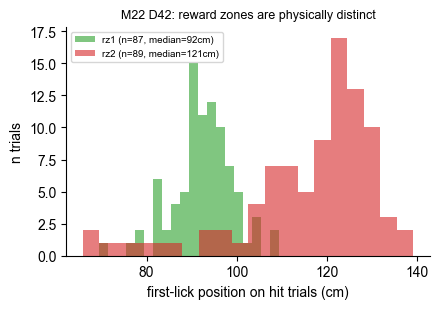

In [7]:
"""
First-lick position on hit trials, split by context -- the reward-location
sanity check the rest of this notebook depends on.
"""
P = data['P']
lick = data['lick']
Pt, Pv = np.array(P.index), np.array(P.values)
lt, lv = np.array(lick.index), np.array(lick.values)

lick_pos_by_ctx = {'rz1': [], 'rz2': []}
for _, row in trials_df.iterrows():
    if row['performance'] != 'hit':
        continue
    m = (lt >= row['start']) & (lt < row['end']) & (lv > 0)
    if m.sum() == 0:
        continue
    pm = (Pt >= row['start']) & (Pt < row['end'])
    lick_pos_by_ctx[row['context']].append(np.median(np.interp(lt[m], Pt[pm], Pv[pm])))

fig, ax = plt.subplots(figsize=(4.5, 3.2))
for ctx, color in [('rz1', CTX1_COLOR), ('rz2', CTX2_COLOR)]:
    vals = np.array(lick_pos_by_ctx[ctx])
    ax.hist(vals, bins=20, alpha=0.6, color=color, label=f'{ctx} (n={len(vals)}, median={np.median(vals):.0f}cm)')
ax.set_xlabel('first-lick position on hit trials (cm)')
ax.set_ylabel('n trials')
ax.set_title(f'{example_mouse} D{example_day}: reward zones are physically distinct', fontsize=9)
ax.legend(fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_reward_zone_locations.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [8]:
"""
Batch behavioural summary: hit rate and reward rate per mouse, day, context.
`day_rank` is the session's ordinal position for that mouse (1st, 2nd, ...
recording day) rather than the raw day-of-experiment number, since mice
have gaps in their recording schedule (e.g. M27: days 25,27,28,29,30) --
day_rank is the meaningful learning-time axis, not the absolute day number.
"""
behaviour_rows = []
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    try:
        df = nap.load_file(f)['trials'].as_dataframe()
    except Exception as e:
        print('FAILED to load', f, e)
        continue
    for ctx in ['rz1', 'rz2']:
        sub = df[df['context'] == ctx]
        if len(sub) == 0:
            continue
        behaviour_rows.append(dict(
            mouse=mouse, day=day, context=ctx, n_trials=len(sub),
            hit_rate=(sub['performance'] == 'hit').mean(),
            reward_rate=(sub['result'] == 'rewarded').mean(),
        ))
behaviour_df = pd.DataFrame(behaviour_rows)
behaviour_df['day_rank'] = behaviour_df.groupby('mouse')['day'].rank(method='dense').astype(int)
behaviour_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_behaviour_summary.csv'), index=False)
print(f'{len(behaviour_df)} mouse x day x context rows, '
      f'{behaviour_df.mouse.nunique()} mice, day_rank range '
      f'[{behaviour_df.day_rank.min()}, {behaviour_df.day_rank.max()}]')
behaviour_df.head()

62 mouse x day x context rows, 6 mice, day_rank range [1, 6]


,mouse,day,context,n_trials,hit_rate,reward_rate,day_rank
0,M22,42,rz1,120,0.725000,0.725000,1
1,M22,42,rz2,109,0.816514,0.816514,1
2,M22,43,rz1,108,0.935185,0.944444,2
3,M22,43,rz2,100,0.990000,0.990000,2
4,M22,44,rz1,103,0.815534,0.815534,3


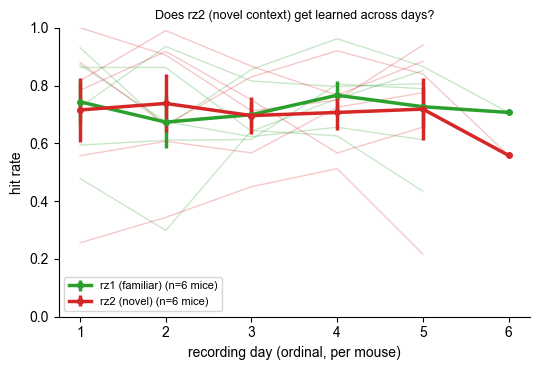

rz1: corr(day_rank, hit_rate) = -0.00, p=0.999 (n=31 mouse-day rows)
rz2: corr(day_rank, hit_rate) = -0.09, p=0.642 (n=31 mouse-day rows)


In [9]:
"""
Learning curves: hit rate vs. day_rank, split by context. Thin lines are
individual mice (so real variability stays visible, not just group
statistics); thick line is the across-mice mean +/- SEM. rz2 (novel context)
should start lower than rz1 (familiar) on day 1 and converge with it if
learning happens within the recording window -- shown honestly even if the
convergence isn't as clean as it looked by eye during the experiment.
"""
fig, ax = plt.subplots(figsize=(5.5, 3.8))
for ctx, color, label in [('rz1', CTX1_COLOR, 'rz1 (familiar)'), ('rz2', CTX2_COLOR, 'rz2 (novel)')]:
    sub = behaviour_df[behaviour_df['context'] == ctx]
    for mouse, g in sub.groupby('mouse'):
        g = g.sort_values('day_rank')
        ax.plot(g['day_rank'], g['hit_rate'], color=color, alpha=0.25, linewidth=1)
    stats = sub.groupby('day_rank')['hit_rate'].agg(['mean', 'sem'])
    ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linewidth=2.5,
                marker='o', markersize=4, label=f'{label} (n={sub.mouse.nunique()} mice)')
ax.set_xlabel('recording day (ordinal, per mouse)')
ax.set_ylabel('hit rate')
ax.set_ylim(0, 1)
ax.set_title('Does rz2 (novel context) get learned across days?', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_learning_curves.pdf'), dpi=200, bbox_inches='tight')
plt.show()

from scipy.stats import spearmanr
for ctx in ['rz1', 'rz2']:
    sub = behaviour_df[behaviour_df['context'] == ctx]
    r, p = spearmanr(sub['day_rank'], sub['hit_rate'])
    print(f'{ctx}: corr(day_rank, hit_rate) = {r:.2f}, p={p:.3f} (n={len(sub)} mouse-day rows)')

### Trial type matters too: cued vs. uncued

Independently of context, every trial is also either **cued** (`b`, the
reward zone itself is signaled) or **uncued** (`nb`, the reward zone is
not signaled -- the animal must rely on distance run through the
always-visible context wall pattern, plus memory) -- randomly interleaved
trial-by-trial within each context block, not itself blocked (checked
directly: no sub-block structure in `type`). These are genuinely different
task conditions, and pooling over them risks hiding exactly the effect
being looked for: *if* there's a learning signal in the data, it's most
plausibly concentrated in the hardest condition (`rz2`+`nb`: novel context
AND no signal) and diluted by averaging it in with the easiest one
(`rz1`+`b`). Everything behavioural and neural below is therefore reported
at the full context x type resolution, not just by context.

In [10]:
"""
Same batch summary as above, at full (context, type) resolution -- b and
nb trials are randomly interleaved within each context block (not
themselves blocked), so this is a genuine 2x2 stratification, not a second
level of blocking.
"""
behaviour_type_rows = []
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    try:
        df = nap.load_file(f)['trials'].as_dataframe()
    except Exception as e:
        print('FAILED to load', f, e)
        continue
    for ctx in ['rz1', 'rz2']:
        for ttype in ['b', 'nb']:
            sub = df[(df['context'] == ctx) & (df['type'] == ttype)]
            if len(sub) == 0:
                continue
            behaviour_type_rows.append(dict(
                mouse=mouse, day=day, context=ctx, type=ttype, n_trials=len(sub),
                hit_rate=(sub['performance'] == 'hit').mean(),
                reward_rate=(sub['result'] == 'rewarded').mean(),
            ))
behaviour_type_df = pd.DataFrame(behaviour_type_rows)
behaviour_type_df['day_rank'] = behaviour_type_df.groupby('mouse')['day'].rank(method='dense').astype(int)
behaviour_type_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_behaviour_by_type_summary.csv'), index=False)
print(f'{len(behaviour_type_df)} mouse x day x context x type rows')
behaviour_type_df.groupby(['context', 'type'])['hit_rate'].agg(['mean', 'std', 'count'])

124 mouse x day x context x type rows


mean       std  count
context type                           
rz1     b     0.863957  0.124750     31
        nb    0.584775  0.224911     31
rz2     b     0.858501  0.148708     31
        nb    0.569214  0.277788     31

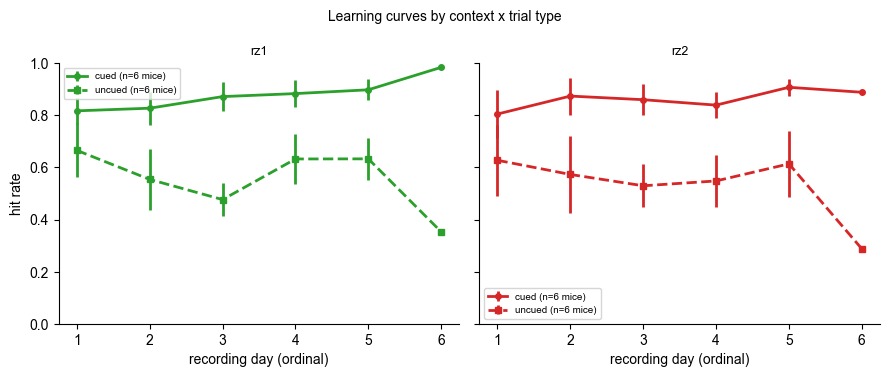

corr(day_rank, hit_rate) per condition:
rz1-b: r=0.31, p=0.089 (n=31 mouse-day rows)
rz1-nb: r=-0.05, p=0.784 (n=31 mouse-day rows)
rz2-b: r=0.05, p=0.793 (n=31 mouse-day rows)
rz2-nb: r=-0.10, p=0.577 (n=31 mouse-day rows)


In [11]:
"""
Learning curves split by trial type within each context -- 2 panels (one
per context), each with cued (solid) and uncued (dashed) lines.
If learning is concentrated in the hardest condition, the rz2/nb line
should show the clearest trend; if trial type barely matters for the
learning *rate* (only the overall difficulty), the lines within a panel
should move together.
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = behaviour_type_df[(behaviour_type_df['context'] == ctx) & (behaviour_type_df['type'] == ttype)]
        stats = sub.groupby('day_rank')['hit_rate'].agg(['mean', 'sem'])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=f'{TYPE_LABEL[ttype]} (n={sub.mouse.nunique()} mice)')
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('recording day (ordinal)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('hit rate')
fig.suptitle('Learning curves by context x trial type', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_learning_curves_by_type.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print('corr(day_rank, hit_rate) per condition:')
for ctx in ['rz1', 'rz2']:
    for ttype in ['b', 'nb']:
        sub = behaviour_type_df[(behaviour_type_df['context'] == ctx) & (behaviour_type_df['type'] == ttype)]
        r, p = spearmanr(sub['day_rank'], sub['hit_rate'])
        print(f'{ctx}-{ttype}: r={r:.2f}, p={p:.3f} (n={len(sub)} mouse-day rows)')

### Speed-profile efficiency: how well is the task being executed, not just whether it's rewarded

`hit`/`try`/`run`/`slow` performance labels are coarse. The task's actual
goal is throughput: **stop at the reward zone and collect as many rewards
as possible in the ~30-minute recording**, which rewards both accuracy
(stopping in the right place) and speed (not wasting time getting there).
Two complementary measures, both stratified by context x type:

1. **Trial duration** -- the direct throughput measure: shorter trials
   mean more attempts (and more reward opportunities) fit in a fixed
   recording length.
2. **Speed-profile shape** -- the full position-binned running-speed trace
   per trial, deliberately **not** restricted to `moving` epochs (unlike
   the position tuning curves used for anchoring below) -- the whole point
   here is to see the deceleration-to-stop itself, which stationary-epoch
   filtering would remove. A single **global** PCA across every trial in
   the dataset (pooled across sessions, not fit per-session) gives one
   common space to compare profile "types" across contexts, trial types,
   blocks, and days on the same axes.

In [12]:
"""
Batch-build per-trial speed profiles (position-binned running speed, full
trial epoch) and trial duration for every session, pooled into one big
trial-level table + one big [n_trials, n_bins] matrix for a single global
PCA. Reuses the same dt/travel trick as everywhere else in this notebook,
applied to the continuous speed variable via
`compute_1d_tuning_curves_continuous` instead of spike-based tuning curves.
"""
speed_trial_rows = []
speed_profiles_all = []

for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    try:
        data = nap.load_file(f)
        trials_df = data['trials'].as_dataframe()
    except Exception as e:
        print('FAILED to load', f, e)
        continue
    n_trials = len(trials_df)
    if n_trials == 0:
        continue

    ctx = trials_df['context'].values
    block = np.zeros(n_trials, dtype=int)
    block[1:] = np.cumsum(ctx[1:] != ctx[:-1])
    trials_df = trials_df.copy()
    trials_df['block'] = block
    trials_df['block_within_context'] = (
        trials_df.groupby('context')['block'].rank(method='dense').astype(int) - 1
    )
    trials_df['duration'] = trials_df['end'] - trials_df['start']

    tns = data['trial_number']
    travel = data['travel']
    dt = travel - (float(tns.values[0]) - 1) * TL
    n_bins_per_trial = int(TL / BS)
    S_frame = nap.TsdFrame(t=data['S'].index, d=np.array(data['S'].values).reshape(-1, 1))
    tc = nap.compute_1d_tuning_curves_continuous(
        S_frame, dt, nb_bins=n_trials * n_bins_per_trial, minmax=[0, n_trials * TL]
    )
    profiles = np.nan_to_num(np.array(tc)).reshape(n_trials, n_bins_per_trial)

    for i, row in enumerate(trials_df.itertuples()):
        speed_trial_rows.append(dict(
            mouse=mouse, day=day, context=row.context, type=row.type,
            performance=row.performance, result=row.result,
            block_within_context=row.block_within_context, duration=row.duration,
            trial_idx=len(speed_trial_rows),
        ))
        speed_profiles_all.append(profiles[i])

speed_trial_df = pd.DataFrame(speed_trial_rows)
speed_trial_df['day_rank'] = speed_trial_df.groupby('mouse')['day'].rank(method='dense').astype(int)
speed_profiles_all = np.array(speed_profiles_all)
np.save(os.path.join(CACHE_DIR, 'mcvr_speed_profiles.npy'), speed_profiles_all)
speed_trial_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_speed_trial_table.csv'), index=False)
print(f'{len(speed_trial_df)} trials pooled across {speed_trial_df.mouse.nunique()} mice, '
      f'speed_profiles_all shape {speed_profiles_all.shape}')

6521 trials pooled across 6 mice, speed_profiles_all shape (6521, 115)


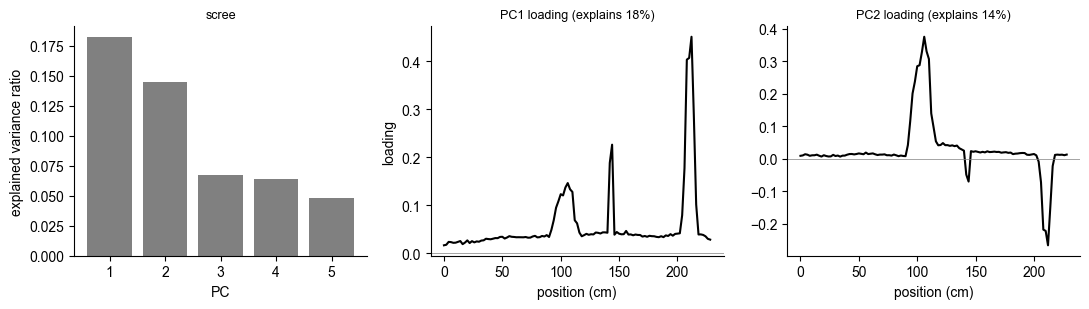

In [13]:
"""
Global PCA on the pooled speed-profile matrix (every trial, every mouse,
every day, in one common space). Scree plot for the first 5 components,
plus the spatial shape of PC1/PC2's loadings so the components are
interpretable (e.g. "overall running vigour" vs. "how sharply the animal
decelerates approaching the reward zone") rather than abstract numbers.
"""
speed_pca = PCA(n_components=5)
speed_scores = speed_pca.fit_transform(speed_profiles_all)
for i in range(3):
    speed_trial_df[f'speed_pc{i+1}'] = speed_scores[:, i]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
ax = axes[0]
ax.bar(range(1, 6), speed_pca.explained_variance_ratio_, color='grey')
ax.set_xlabel('PC'); ax.set_ylabel('explained variance ratio')
ax.set_title('scree', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

pos_axis = np.arange(int(TL / BS)) * BS
for ax, pc_i, label in [(axes[1], 0, 'PC1'), (axes[2], 1, 'PC2')]:
    ax.plot(pos_axis, speed_pca.components_[pc_i], color='k')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_xlabel('position (cm)')
    ax.set_title(f'{label} loading (explains {speed_pca.explained_variance_ratio_[pc_i]:.0%})', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
axes[1].set_ylabel('loading')
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_speed_pca_components.pdf'), dpi=200, bbox_inches='tight')
plt.show()

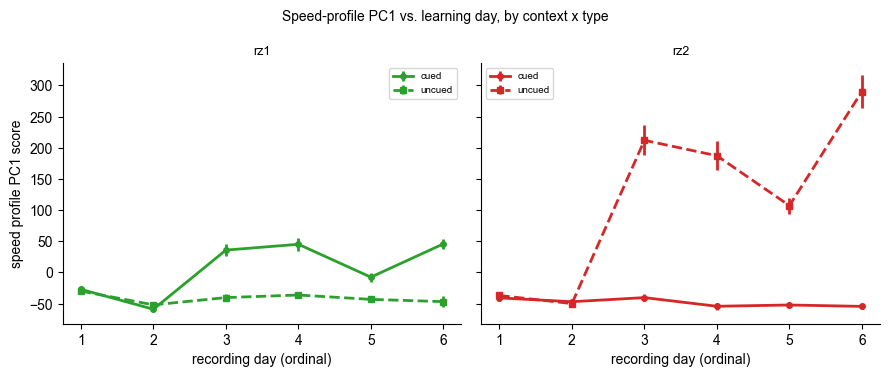

corr(day_rank, speed PC1), all trials pooled: r=0.10, p=0.000


In [14]:
"""
Where do these speed-profile PC scores show up -- by context x type, by
recording day, and by block-within-context (position within the session)?
Colour = context, linestyle = type, matching the behavioural learning-curve
convention above so panels are directly comparable.
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = speed_trial_df[(speed_trial_df['context'] == ctx) & (speed_trial_df['type'] == ttype)]
        stats = sub.groupby('day_rank')['speed_pc1'].agg(['mean', 'sem'])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('recording day (ordinal)')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('speed profile PC1 score')
fig.suptitle('Speed-profile PC1 vs. learning day, by context x type', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_speed_pc1_vs_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()

r, p = spearmanr(speed_trial_df['day_rank'], speed_trial_df['speed_pc1'])
print(f'corr(day_rank, speed PC1), all trials pooled: r={r:.2f}, p={p:.3f}')

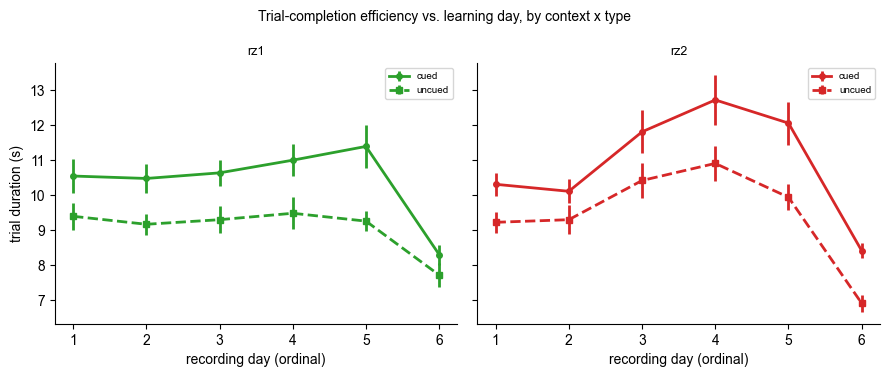

rz1-b: corr(day_rank, duration) r=0.05, p=0.060 (n=1608 trials)
rz1-nb: corr(day_rank, duration) r=0.03, p=0.199 (n=1656 trials)
rz2-b: corr(day_rank, duration) r=0.07, p=0.003 (n=1668 trials)
rz2-nb: corr(day_rank, duration) r=0.02, p=0.337 (n=1589 trials)


In [15]:
"""
Efficiency (trial duration) vs. learning day, same context x type layout --
the direct throughput measure tied to the task's actual goal (rewards per
recording). Shorter duration = more efficient. This can move independently
of hit rate: a mouse could get *faster* at completing trials without
necessarily getting more *accurate*.
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = speed_trial_df[(speed_trial_df['context'] == ctx) & (speed_trial_df['type'] == ttype)]
        stats = sub.groupby('day_rank')['duration'].agg(['mean', 'sem'])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('recording day (ordinal)')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('trial duration (s)')
fig.suptitle('Trial-completion efficiency vs. learning day, by context x type', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_efficiency_vs_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()

for ctx in ['rz1', 'rz2']:
    for ttype in ['b', 'nb']:
        sub = speed_trial_df[(speed_trial_df['context'] == ctx) & (speed_trial_df['type'] == ttype)]
        r, p = spearmanr(sub['day_rank'], sub['duration'])
        print(f'{ctx}-{ttype}: corr(day_rank, duration) r={r:.2f}, p={p:.3f} (n={len(sub)} trials)')

### Where does the animal actually stop, trial by trial?

Trial duration and speed-profile PC1 (above) summarize the whole trial as
one number; a more direct behavioural readout of task mastery is *where on
the track the animal settles into a stop* -- a mouse that has learned
`rz2` should stop tightly at its reward position from early on, while a
mouse still learning it might stop short, overshoot, or not commit to a
stop at all (a `run` trial). This is computed straight from the pooled
speed profiles above (no NWB reload): the earliest position bin from which
speed stays below a stricter "has settled" threshold for the rest of the
trial. Shown per mouse (not just pooled) since this is exactly the kind of
per-animal trajectory that a group mean can hide.

In [16]:
"""
Stop position per trial. The track continues past the reward zone up to
the fixed per-trial extent (TL=230cm) rather than ending there, so a real
reward-zone stop shows up as a **localized dip** in the speed profile
(the animal slows, then resumes running to trigger the next trial), not a
sustained stop lasting to the end of the trial's binned range -- an
earlier version of this cell assumed the latter and silently detected 0%
of stops as a result. Fixed here: for each trial, find the longest
contiguous run of bins with speed below STOP_SPEED_THRESH; its midpoint is
the stop position, if the run is at least MIN_STOP_BINS long. Validated
directly against the independent first-lick-position check from Part A
(median hit-trial stop position lands within 1cm of the lick-based
rz1/rz2 medians there).
"""
STOP_SPEED_THRESH = 10.0   # cm/s -- calibrated against the longest-run length distribution, not MIN_SPEED
MIN_STOP_BINS = 2          # >=4cm of contiguous low speed to count as a real stop, not one noisy sample

def _longest_run(row, thresh):
    below = row < thresh
    best_start, best_len, cur_start, cur_len = -1, 0, -1, 0
    for i, v in enumerate(below):
        if v:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_len, best_start = cur_len, cur_start
        else:
            cur_len = 0
    return best_start, best_len

stop_positions = np.full(len(speed_profiles_all), np.nan)
for i, prof in enumerate(speed_profiles_all):
    start, length = _longest_run(prof, STOP_SPEED_THRESH)
    if length >= MIN_STOP_BINS:
        stop_positions[i] = (start + length / 2) * BS
speed_trial_df['stop_position'] = stop_positions
speed_trial_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_speed_trial_table.csv'), index=False)

print(f'{speed_trial_df.stop_position.notna().mean():.0%} of trials have a detectable stop')
print('fraction with a detectable stop, by performance label:')
print(speed_trial_df.groupby('performance')['stop_position'].apply(lambda s: s.notna().mean()))
print()
print('sanity check vs. Part A\'s independent lick-based reward-zone check:')
print(speed_trial_df[speed_trial_df['performance'] == 'hit'].groupby('context')['stop_position'].median())

70% of trials have a detectable stop
fraction with a detectable stop, by performance label:
performance
hit     0.818811
run     0.338562
slow    0.971910
try     0.421960
Name: stop_position, dtype: float64

sanity check vs. Part A's independent lick-based reward-zone check:
context
rz1     92.0
rz2    122.0
Name: stop_position, dtype: float64


reference (median hit-trial stop position): {'rz1': np.float64(92.0), 'rz2': np.float64(122.0)}


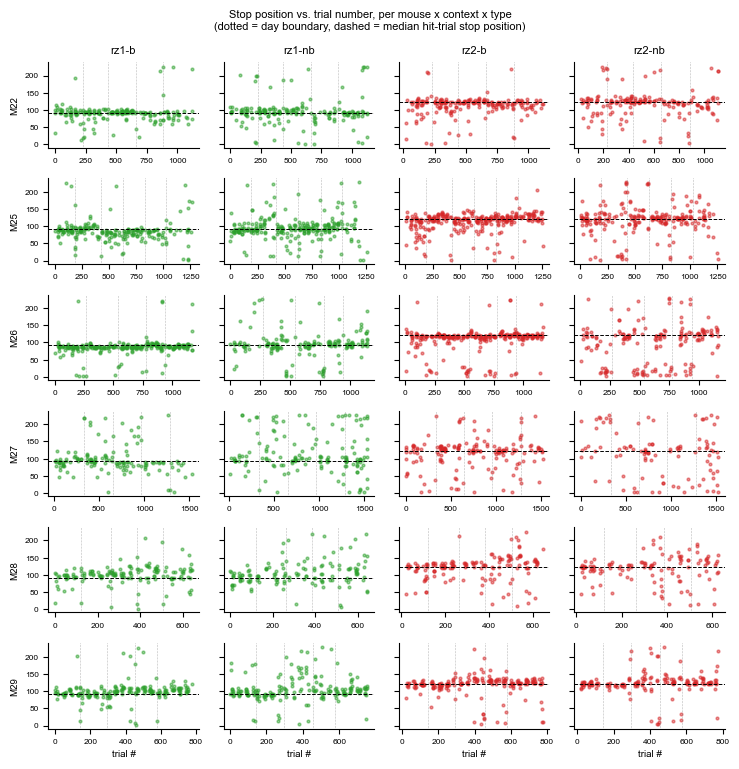

In [17]:
"""
Per-mouse, per-context, per-type: stop position vs. trial number, with
trial number running continuously across all of that mouse's recorded
days (not reset each session) so a within-mouse shift toward the true
reward position, if any, should be visible as a trend across the panel.
Dotted vertical lines mark day boundaries; the dashed horizontal line is
the median stop position on that context's hit trials (pooled across
everyone), i.e. the empirical reward-zone position.
"""
speed_trial_df_sorted = speed_trial_df.sort_values(['mouse', 'day', 'trial_idx']).copy()
speed_trial_df_sorted['session_trial_num'] = speed_trial_df_sorted.groupby('mouse').cumcount()

reward_zone_ref = (speed_trial_df_sorted[speed_trial_df_sorted['performance'] == 'hit']
                    .groupby('context')['stop_position'].median())
print('reference (median hit-trial stop position):', dict(reward_zone_ref))

mice_list = sorted(speed_trial_df_sorted['mouse'].unique())
conditions = [('rz1', 'b', CTX1_COLOR), ('rz1', 'nb', CTX1_COLOR),
              ('rz2', 'b', CTX2_COLOR), ('rz2', 'nb', CTX2_COLOR)]
fig, axes = plt.subplots(len(mice_list), 4, figsize=(7.5, 1.3 * len(mice_list)), sharey=True)
for mi, mouse in enumerate(mice_list):
    msub = speed_trial_df_sorted[speed_trial_df_sorted['mouse'] == mouse]
    day_bounds = msub.groupby('day')['session_trial_num'].min().values[1:]
    for ci, (ctx, ttype, color) in enumerate(conditions):
        ax = axes[mi, ci]
        csub = msub[(msub['context'] == ctx) & (msub['type'] == ttype)]
        ax.scatter(csub['session_trial_num'], csub['stop_position'], s=4, alpha=0.5, color=color)
        for db in day_bounds:
            ax.axvline(db, color='grey', linewidth=0.4, linestyle=':')
        ax.axhline(reward_zone_ref[ctx], color='k', linewidth=0.7, linestyle='--')
        if mi == 0:
            ax.set_title(f'{ctx}-{ttype}', fontsize=8)
        if ci == 0:
            ax.set_ylabel(mouse, fontsize=7)
        ax.tick_params(labelsize=6)
        ax.spines[['top', 'right']].set_visible(False)
        if mi == len(mice_list) - 1:
            ax.set_xlabel('trial #', fontsize=7)
fig.suptitle('Stop position vs. trial number, per mouse x context x type\n'
             '(dotted = day boundary, dashed = median hit-trial stop position)', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_stop_position_by_mouse.pdf'), dpi=200, bbox_inches='tight')
plt.show()

### Stop position and block hit rate, side by side, every day, per mouse

The panel above shows stop position alone, all four conditions in
separate small subplots. Here cued and uncued are pulled fully apart into
their own stop-position panels, each paired directly with that
condition's block-level hit rate on the same trial-number axis -- so a
block that looks noisy or off-target in the stop-position panel can be
checked immediately against whether it was also a low-hit-rate block.
5 columns, one figure per mouse: **(1)** all contexts x types together,
**(2)** cued stops only (both contexts), **(3)** cued hit rate per block
(both contexts, narrow), **(4)** uncued stops only (both contexts),
**(5)** uncued hit rate per block (both contexts, narrow). Thin grey
lines mark context-block boundaries; bold blue lines mark day boundaries
-- a different colour specifically so the two kinds of boundary aren't
confused at a glance.

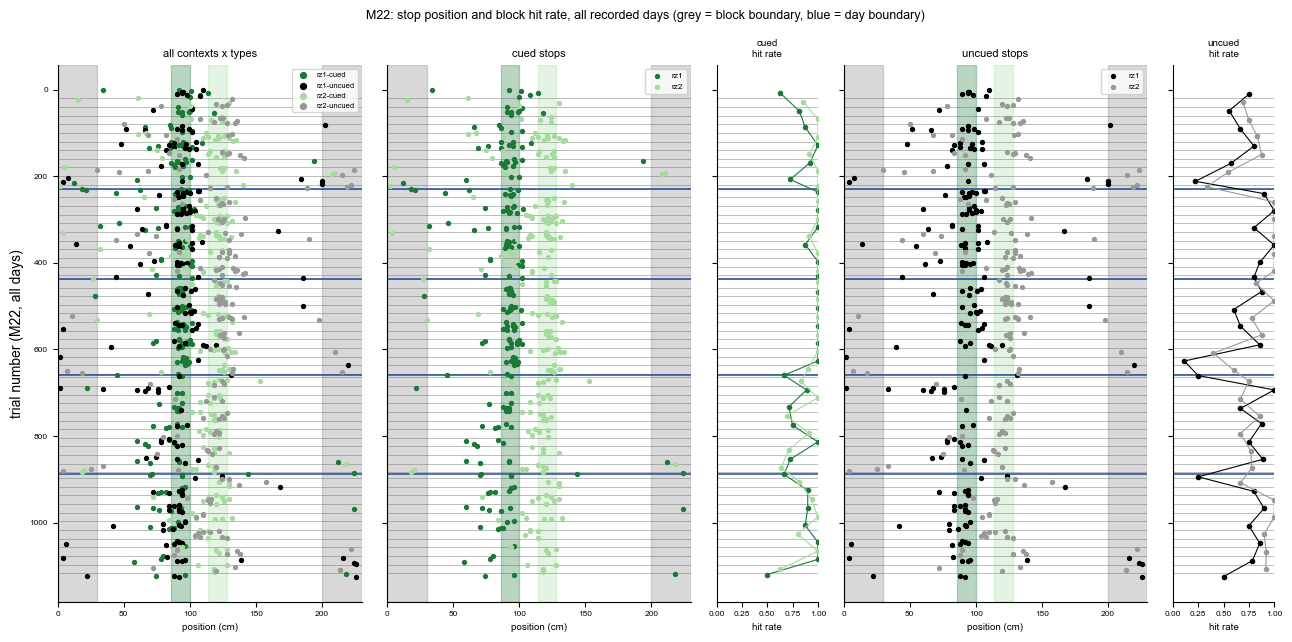

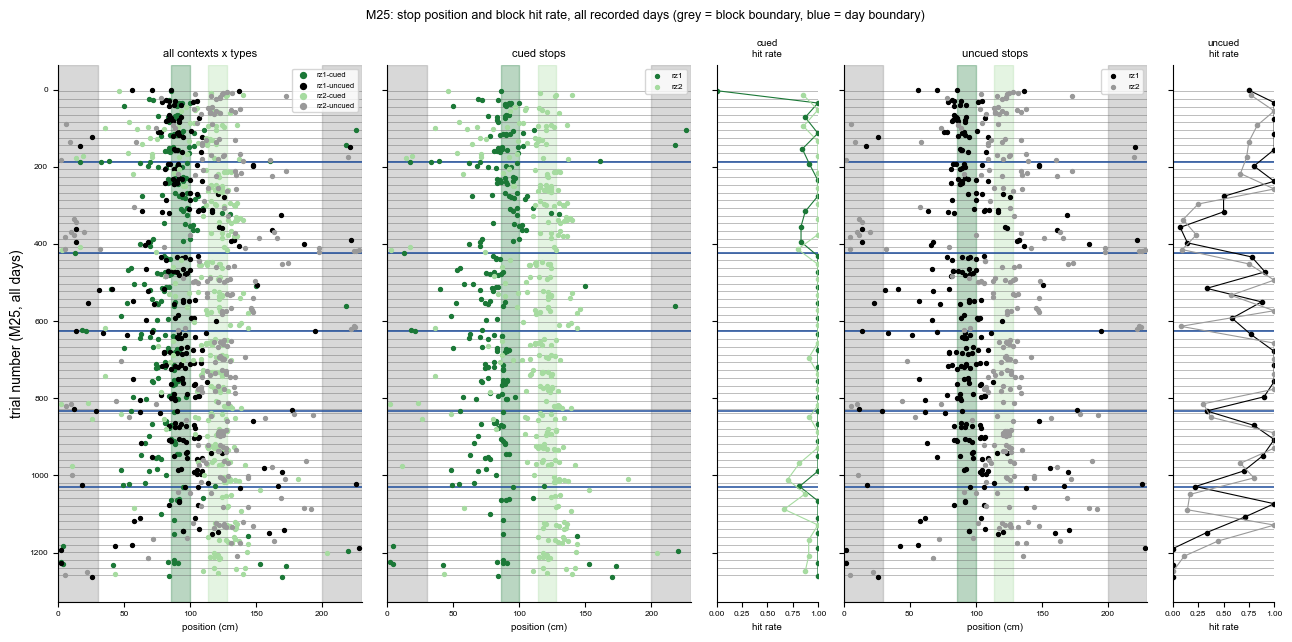

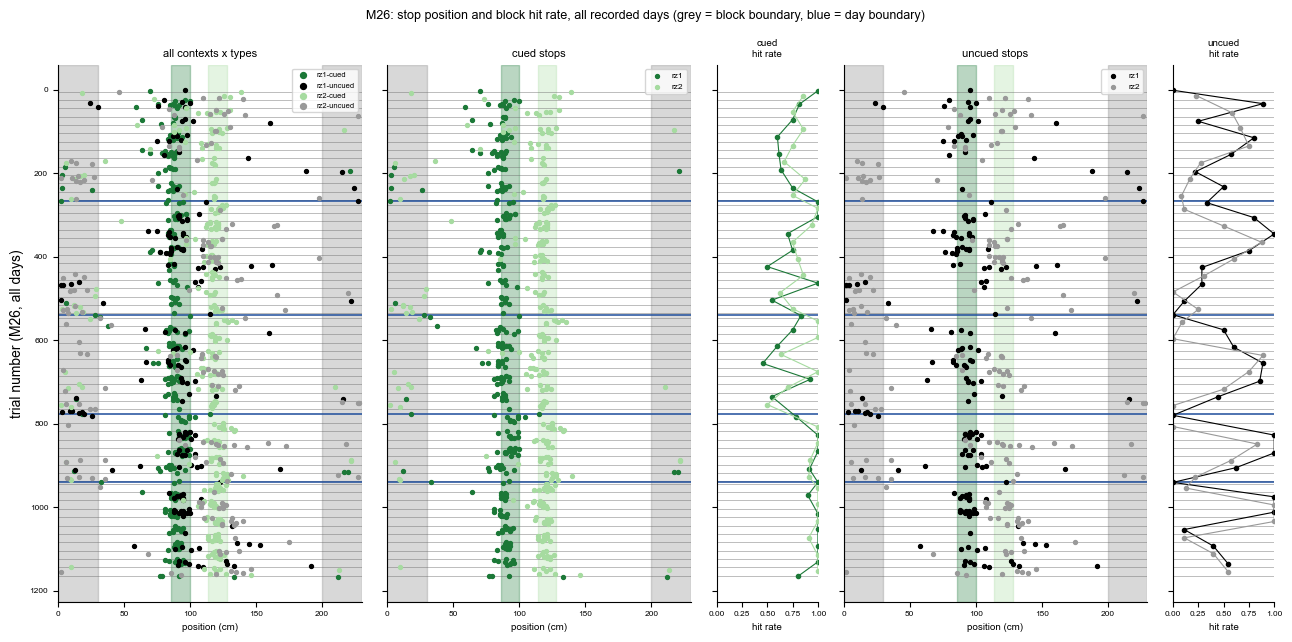

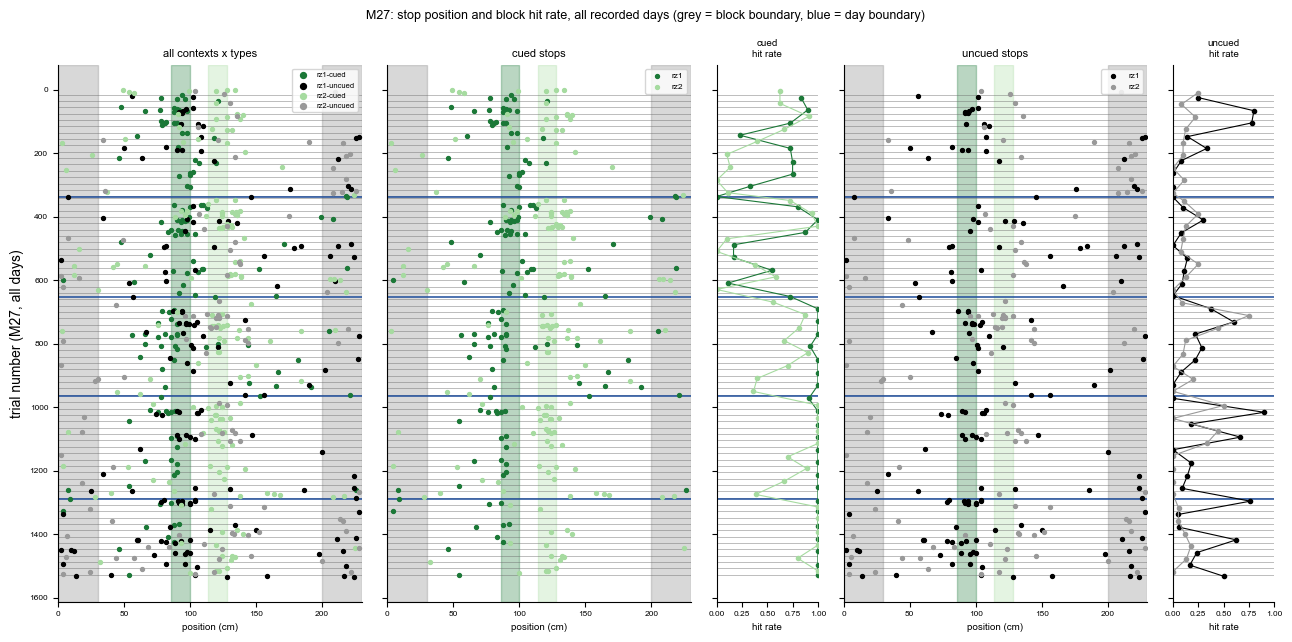

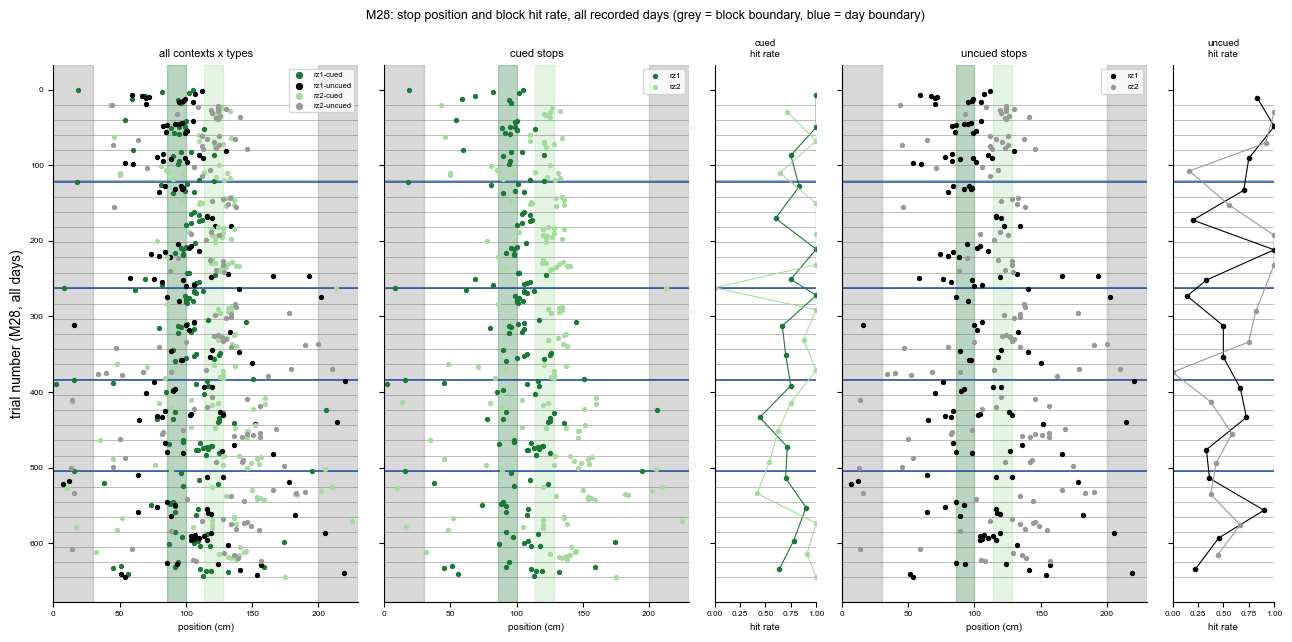

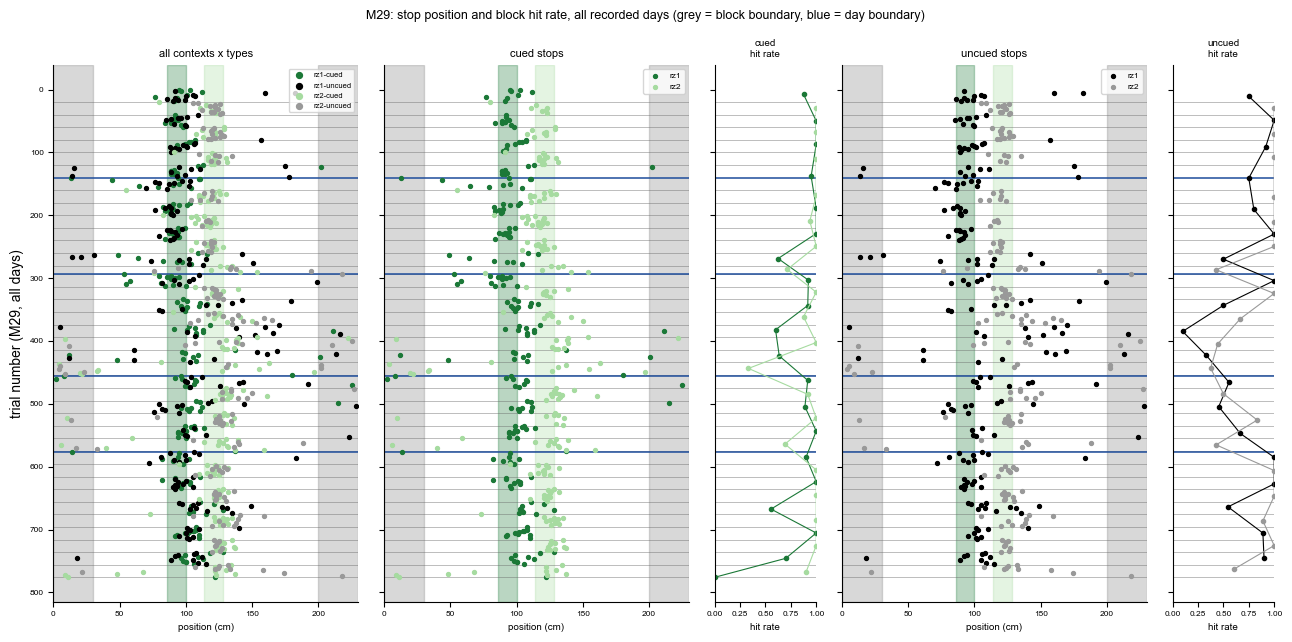

In [18]:
"""
All days, one figure per mouse. Reuses speed_trial_df (built above, has
stop_position + performance for every trial, every mouse, every day) --
no NWB reload needed.
"""
GREEN1, GREEN2 = '#1b7837', '#a6dba0'   # dark green = rz1-cued, light green = rz2-cued
STOP_COND_COLOR = {('rz1', 'b'): GREEN1, ('rz2', 'b'): GREEN2, ('rz1', 'nb'): 'black', ('rz2', 'nb'): '0.6'}
RZ_BOUNDS = {'rz1': (SCHEMATIC_RZ['rz1']['lo'], SCHEMATIC_RZ['rz1']['hi']),
             'rz2': (SCHEMATIC_RZ['rz2']['lo'], SCHEMATIC_RZ['rz2']['hi'])}
DAY_LINE_COLOR = '#1f4e9c'  # bold blue -- deliberately distinct from the thin grey block lines

plot_df = speed_trial_df.sort_values(['mouse', 'trial_idx']).reset_index(drop=True)
plot_df['hit'] = (plot_df['performance'] == 'hit').astype(float)

def shade_track(ax):
    ax.axvspan(0, BOX_WIDTH, color='0.5', alpha=0.3, zorder=0)
    ax.axvspan(TL - BOX_WIDTH, TL, color='0.5', alpha=0.3, zorder=0)
    ax.axvspan(*RZ_BOUNDS['rz1'], color=GREEN1, alpha=0.3, zorder=0)
    ax.axvspan(*RZ_BOUNDS['rz2'], color=GREEN2, alpha=0.3, zorder=0)

for mouse in sorted(plot_df['mouse'].unique()):
    m_df = plot_df[plot_df['mouse'] == mouse].sort_values('trial_idx').reset_index(drop=True)
    m_df['y_pos'] = np.arange(len(m_df))

    ctx_arr = m_df['context'].values
    block = np.zeros(len(ctx_arr), dtype=int)
    block[1:] = np.cumsum(ctx_arr[1:] != ctx_arr[:-1])
    m_df['block'] = block
    block_starts = m_df.groupby('block')['y_pos'].min().values[1:]

    day_change = (m_df['day'] != m_df['day'].shift()).values
    day_starts = m_df.loc[day_change, 'y_pos'].values[1:]

    block_summary = (m_df.groupby(['block', 'context', 'type'])
                      .agg(hit_rate=('hit', 'mean'), y_mid=('y_pos', 'mean')).reset_index())

    fig, axes = plt.subplots(1, 5, figsize=(13, 6.5), sharey=True,
                              gridspec_kw={'width_ratios': [3, 3, 1, 3, 1]})

    def draw_boundaries(ax):
        for b in block_starts:
            ax.axhline(b, color='0.4', linewidth=0.5, alpha=0.6, zorder=1)
        for d in day_starts:
            ax.axhline(d, color=DAY_LINE_COLOR, linewidth=1.3, alpha=0.85, zorder=1)

    # column 1: all contexts x types
    ax = axes[0]
    shade_track(ax)
    for (ctx, ttype), g in m_df.groupby(['context', 'type']):
        g2 = g.dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=8, color=STOP_COND_COLOR[(ctx, ttype)],
                   label=f'{ctx}-{TYPE_LABEL[ttype]}', zorder=2)
    draw_boundaries(ax)
    ax.set_xlim(0, TL)
    ax.set_title('all contexts x types', fontsize=8)
    ax.legend(fontsize=5.5, markerscale=1.5, loc='upper right')

    # column 2: cued stops, both contexts
    ax = axes[1]
    shade_track(ax)
    for ctx, color in [('rz1', GREEN1), ('rz2', GREEN2)]:
        g2 = m_df[(m_df['context'] == ctx) & (m_df['type'] == 'b')].dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=8, color=color, label=ctx, zorder=2)
    draw_boundaries(ax)
    ax.set_xlim(0, TL)
    ax.set_title('cued stops', fontsize=8)
    ax.legend(fontsize=6, loc='upper right')

    # column 3: cued hit rate by block, both contexts (narrow)
    ax = axes[2]
    for ctx, color in [('rz1', GREEN1), ('rz2', GREEN2)]:
        bsub = block_summary[(block_summary['context'] == ctx) & (block_summary['type'] == 'b')]
        ax.plot(bsub['hit_rate'], bsub['y_mid'], color=color, marker='o', markersize=3, linewidth=0.8)
    draw_boundaries(ax)
    ax.set_xlim(0, 1)
    ax.set_title('cued\nhit rate', fontsize=7)

    # column 4: uncued stops, both contexts
    ax = axes[3]
    shade_track(ax)
    for ctx, color in [('rz1', 'black'), ('rz2', '0.6')]:
        g2 = m_df[(m_df['context'] == ctx) & (m_df['type'] == 'nb')].dropna(subset=['stop_position'])
        ax.scatter(g2['stop_position'], g2['y_pos'], s=8, color=color, label=ctx, zorder=2)
    draw_boundaries(ax)
    ax.set_xlim(0, TL)
    ax.set_title('uncued stops', fontsize=8)
    ax.legend(fontsize=6, loc='upper right')

    # column 5: uncued hit rate by block, both contexts (narrow)
    ax = axes[4]
    for ctx, color in [('rz1', 'black'), ('rz2', '0.6')]:
        bsub = block_summary[(block_summary['context'] == ctx) & (block_summary['type'] == 'nb')]
        ax.plot(bsub['hit_rate'], bsub['y_mid'], color=color, marker='o', markersize=3, linewidth=0.8)
    draw_boundaries(ax)
    ax.set_xlim(0, 1)
    ax.set_title('uncued\nhit rate', fontsize=7)

    axes[0].invert_yaxis()
    axes[0].set_ylabel(f'trial number ({mouse}, all days)')
    for ax in [axes[0], axes[1], axes[3]]:
        ax.set_xlabel('position (cm)', fontsize=7)
    for ax in [axes[2], axes[4]]:
        ax.set_xlabel('hit rate', fontsize=7)
    for ax in axes:
        ax.tick_params(labelsize=6)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'{mouse}: stop position and block hit rate, all recorded days '
                 f'(grey = block boundary, blue = day boundary)', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGPATH, f'mcvr_stop_and_blockhit_{mouse}.pdf'), dpi=200, bbox_inches='tight')
    plt.show()

### A single score for how well each trial was executed

Duration, vigour (PC1), and stop position each capture one facet of "did
this trial look like the task was being done well." Two complementary,
zone-specific scores get closer to the actual task contingency (slow down
*at the reward zone specifically*, not just anywhere):

1. **Zone-specificity ratio** — mean speed in a window around this
   trial's own context's known reward-zone location, divided by mean
   speed in a fixed control window well before either reward zone (a
   stable cruising baseline). Near 0 = clean, specific slowing right at
   the RZ; near 1 = no differential slowing at all (ran straight through).
   This is a ratio, not an absolute speed, so it's naturally normalized
   for how fast a given animal/day cruises overall.
2. **Stop-position error** — `|stop_position - known_RZ_location|` (cm),
   reusing `stop_position` from above. A direct, literal "how many cm off"
   precision score. Left as NaN where no stop was detected, not imputed —
   consistent with how `run`/`try` trials are treated everywhere else in
   this notebook.

Validated below against the `performance` labels before trusting either
one further: both should be best (lowest) on `hit` trials and worst on
`run` trials, since those labels are the closest thing to independent
ground truth already in this dataset.

In [19]:
"""
Compute both scores from the pooled speed-profile matrix, no NWB reload.
A tiny fraction of trials (<1% overall, up to ~3% of 'slow' trials) have a
genuinely near-zero control-window speed (the animal simply hadn't started
moving yet by 20-40cm) -- dividing by that produces inf, and even a
handful of inf values wreck the group mean entirely. Guarded here: a
degenerate baseline (control_speed <= 1 cm/s) makes the ratio NaN rather
than inf, since there's no reliable baseline to compare against, not
because the trial was somehow infinitely bad.
"""
RZ_LOCATION = {'rz1': 92.0, 'rz2': 122.0}   # matches both the lick-based and stop-based checks above
ZONE_HALF_WIDTH = 10.0     # cm
CONTROL_WINDOW = (20.0, 40.0)  # cm -- well clear of the trial-start ramp and both reward zones
MIN_CONTROL_SPEED = 1.0    # cm/s -- below this, no reliable baseline to divide by

bin_centers = (np.arange(speed_profiles_all.shape[1]) + 0.5) * BS
control_mask = (bin_centers >= CONTROL_WINDOW[0]) & (bin_centers < CONTROL_WINDOW[1])
control_speed = speed_profiles_all[:, control_mask].mean(axis=1)

zone_speed = np.full(len(speed_trial_df), np.nan)
context_arr = speed_trial_df['context'].values
for ctx, rz in RZ_LOCATION.items():
    zone_mask = (bin_centers >= rz - ZONE_HALF_WIDTH) & (bin_centers < rz + ZONE_HALF_WIDTH)
    ctx_rows = context_arr == ctx
    zone_speed[ctx_rows] = speed_profiles_all[ctx_rows][:, zone_mask].mean(axis=1)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = zone_speed / control_speed
speed_trial_df['zone_specificity_ratio'] = np.where(control_speed > MIN_CONTROL_SPEED, ratio, np.nan)
speed_trial_df['stop_position_error'] = [
    abs(sp - RZ_LOCATION[ctx]) if pd.notna(sp) else np.nan
    for sp, ctx in zip(speed_trial_df['stop_position'], speed_trial_df['context'])
]
speed_trial_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_speed_trial_table.csv'), index=False)

print(f'{(speed_trial_df["zone_specificity_ratio"].isna()).mean():.1%} of trials excluded '
      f'(degenerate control-window baseline)')
print('validation against performance labels (lower = better trial execution for both):')
print(speed_trial_df.groupby('performance')[['zone_specificity_ratio', 'stop_position_error']]
      .agg(['mean', 'median', 'count']))

0.3% of trials excluded (degenerate control-window baseline)
validation against performance labels (lower = better trial execution for both):
            zone_specificity_ratio                 stop_position_error         \
                              mean    median count                mean median   
performance                                                                     
hit                       0.610840  0.434912  4471           14.283765    7.0   
run                       1.276762  1.112532   760           70.335907   76.0   
slow                      0.832709  0.650393   170           48.832370   35.0   
try                       0.906874  0.878440  1099           46.602151   34.0   

                   
            count  
performance        
hit          3665  
run           259  
slow          173  
try           465  


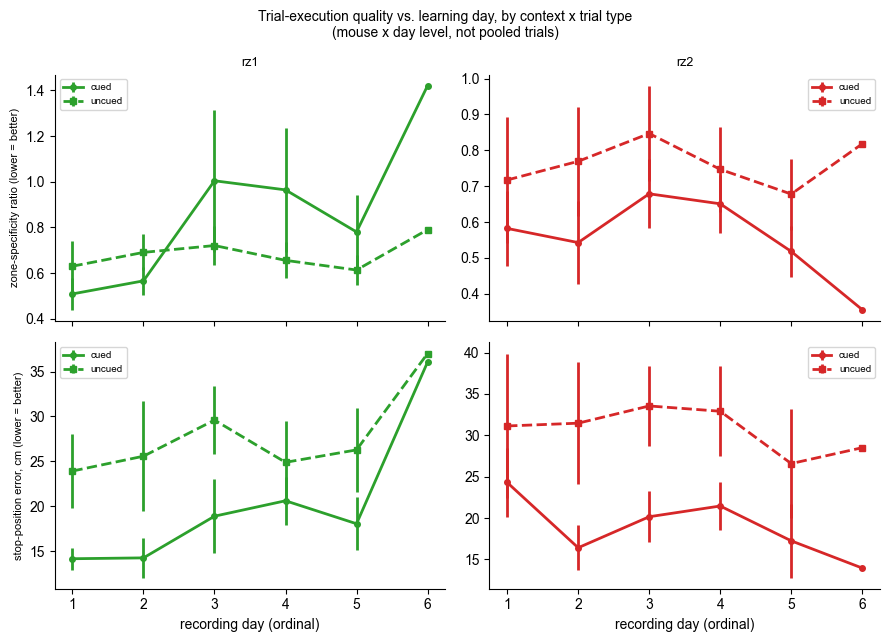

--- zone_specificity_ratio (mouse x day level) ---
rz1-b: r=0.33, p=0.071 (n=31 mouse-day rows)
rz1-nb: r=0.00, p=0.989 (n=31 mouse-day rows)
rz2-b: r=-0.04, p=0.844 (n=31 mouse-day rows)
rz2-nb: r=0.02, p=0.935 (n=31 mouse-day rows)
--- stop_position_error (mouse x day level) ---
rz1-b: r=0.33, p=0.068 (n=31 mouse-day rows)
rz1-nb: r=0.14, p=0.441 (n=31 mouse-day rows)
rz2-b: r=-0.16, p=0.382 (n=31 mouse-day rows)
rz2-nb: r=-0.03, p=0.864 (n=31 mouse-day rows)


In [20]:
"""
Aggregated to mouse x day level first (mean per mouse x day x context x
type), matching the convention every other cross-day test in this
notebook uses -- NOT a raw pooled-trial correlation. That distinction
matters here: an earlier version of this cell correlated day_rank against
thousands of pooled individual trials directly, which found a "significant"
rz2-b improvement (r=-0.12, p<0.001) that evaporated -- and in some mice
reversed -- once checked per mouse (M22/M28/M29 got worse with day,
M25/M26/M27 got better, all individually significant). Pooling raw trials
across mice with unequal trial counts is a Simpson's-paradox risk, and
treating same-day trials as independent samples inflates n and p-value
credibility. Aggregating to one point per mouse x day first avoids both.
"""
quality_daily = (speed_trial_df
                  .groupby(['mouse', 'day', 'day_rank', 'context', 'type'])[['zone_specificity_ratio', 'stop_position_error']]
                  .mean()
                  .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex=True)
metrics = [('zone_specificity_ratio', 'zone-specificity ratio (lower = better)'),
           ('stop_position_error', 'stop-position error, cm (lower = better)')]
for mi, (metric, ylabel) in enumerate(metrics):
    for ci, (ctx, color) in enumerate([('rz1', CTX1_COLOR), ('rz2', CTX2_COLOR)]):
        ax = axes[mi, ci]
        for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
            sub = quality_daily[(quality_daily['context'] == ctx) & (quality_daily['type'] == ttype)]
            stats = sub.groupby('day_rank')[metric].agg(['mean', 'sem'])
            ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                        marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
        if mi == 0:
            ax.set_title(ctx, fontsize=9)
        if ci == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        ax.legend(fontsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        if mi == 1:
            ax.set_xlabel('recording day (ordinal)')
fig.suptitle('Trial-execution quality vs. learning day, by context x trial type\n(mouse x day level, not pooled trials)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_trial_quality_vs_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()

from scipy.stats import spearmanr
for metric, _ in metrics:
    print(f'--- {metric} (mouse x day level) ---')
    for ctx in ['rz1', 'rz2']:
        for ttype in ['b', 'nb']:
            sub = quality_daily[(quality_daily['context'] == ctx) & (quality_daily['type'] == ttype)].dropna(subset=[metric])
            r, p = spearmanr(sub['day_rank'], sub[metric])
            print(f'{ctx}-{ttype}: r={r:.2f}, p={p:.3f} (n={len(sub)} mouse-day rows)')

## Part B: population-wide anchoring dynamics across learning days

Reusing the exact validated method from `trial_cluster_anchoring.ipynb`
(per-cell trial-clustering classifier -> anchored/non-anchored label per
cell per trial) and `session_validity_pc1_significance.ipynb` (PC1 of the
cell x trial label matrix, tested against a circular-shift null) -- copied
here verbatim rather than re-derived, so results are directly comparable to
every other population-anchoring number in this collection.

New here: because `travel` (cumulative distance) plays exactly the same
role as `compute_vr_tcs`'s `dt` even though the file layout differs, the
same single-call-per-session tuning-curve trick applies -- one
`compute_1d_tuning_curves` call per session covers every cell x trial x
position bin at once.

In [21]:
"""
trial_cluster_labels, pc1_explained_var, circular_shift_null -- copied
verbatim from trial_cluster_anchoring.ipynb / session_validity_pc1_significance.ipynb
so this notebook's numbers are directly comparable to the rest of the collection.
"""
def trial_cluster_labels(raw_trials, min_activity=1e-6, min_valid_trials=6, smooth_sigma=1.5, medfilt_size=5):
    n_trials = raw_trials.shape[0]
    smoothed = np.array([gaussian_filter(np.nan_to_num(raw_trials[t]).astype(np.float64), sigma=smooth_sigma)
                          for t in range(n_trials)])
    activity = smoothed.sum(axis=1)
    valid = activity > min_activity
    labels = np.full(n_trials, np.nan)
    if valid.sum() < min_valid_trials:
        return labels
    C = np.corrcoef(smoothed[valid])
    mean_corr = (C.sum(axis=1) - 1) / (C.shape[0] - 1)
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(mean_corr.reshape(-1, 1))
    anchored_cluster = np.argmax(km.cluster_centers_.ravel())
    valid_labels = (km.labels_ == anchored_cluster).astype(float)
    labels[valid] = valid_labels
    labels[~valid] = 0.0
    if medfilt_size:
        labels = median_filter(labels, size=medfilt_size, mode='nearest')
    return labels

def pc1_explained_var(M):
    pca = PCA(n_components=1)
    pca.fit(M)
    return pca.explained_variance_ratio_[0]

def circular_shift_null(M, n_shuffles, rng):
    n_cells, n_trials = M.shape
    null_vals = np.empty(n_shuffles)
    for i in range(n_shuffles):
        shifts = rng.integers(0, n_trials, size=n_cells)
        M_shift = np.array([np.roll(M[c], shifts[c]) for c in range(n_cells)])
        null_vals[i] = pc1_explained_var(M_shift)
    return null_vals


def load_mcvr_label_matrix(mouse, day, source_path=SOURCE_PATH, bs_local=BS, tl_local=TL, min_speed=MIN_SPEED):
    """Per-cell anchored/non-anchored label matrix [n_cells, n_trials] for one
    MCVR session, plus the trials dataframe needed to subset by context."""
    path = os.path.join(source_path, f'sub-{mouse}', f'sub-{mouse}_ses-D{day}MCVR_ecephys+behavior.nwb')
    data = nap.load_file(path)
    curated = curate_clusters(data['units'])
    trials_df = data['trials'].as_dataframe()
    n_trials = len(trials_df)
    if len(curated) == 0 or n_trials == 0:
        return None, None, None

    tns = data['trial_number']
    travel = data['travel']
    moving = data['S'].threshold(min_speed, method='above').time_support
    dt = travel - (float(tns.values[0]) - 1) * tl_local
    n_bins_per_trial = int(tl_local / bs_local)

    tcs = nap.compute_1d_tuning_curves(curated, dt, nb_bins=n_trials * n_bins_per_trial,
                                        minmax=[0, n_trials * tl_local], ep=moving)
    tcs = np.array(tcs)

    label_matrix = np.full((len(curated.index), n_trials), np.nan)
    for ci in range(len(curated.index)):
        raw_trials = tcs[:, ci].reshape(n_trials, n_bins_per_trial)
        label_matrix[ci] = trial_cluster_labels(raw_trials)

    regions = curated.metadata['brain_region'].values
    return label_matrix, trials_df, regions

M22 D42: label_matrix shape (190, 229)


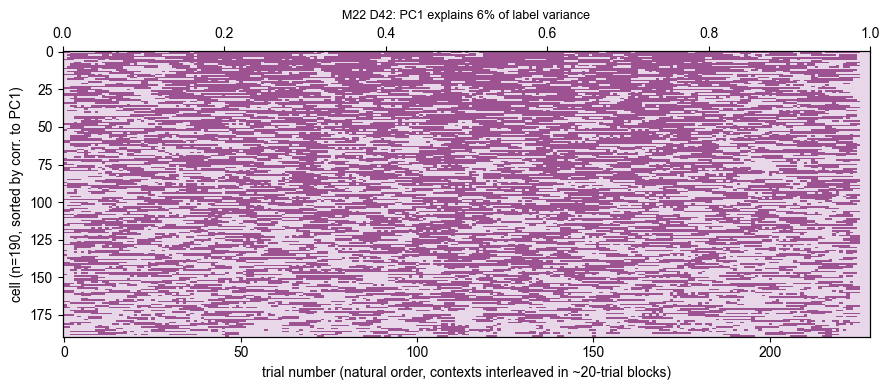

In [22]:
"""
Try the loader + classifier on the example session before batch-running
everything -- same PC1-sorted raster convention used throughout the rest of
`AnchorDynamics2026/`.
"""
label_matrix, ex_trials_df, ex_regions = load_mcvr_label_matrix(example_mouse, example_day)
print(f'{example_mouse} D{example_day}: label_matrix shape {label_matrix.shape}')

M = np.nan_to_num(label_matrix, nan=0.0)
pc1_var = pc1_explained_var(M)
pca = PCA(n_components=1).fit(M)
pc1_corrs = M @ pca.components_[0]
pc1_order = np.argsort(-pc1_corrs)

fig, ax = plt.subplots(figsize=(9, 4))
from matplotlib.colors import ListedColormap, BoundaryNorm
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)
ax.imshow(M[pc1_order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
ctx_strip = (ex_trials_df['context'] == 'rz2').values.astype(float)
ax2 = ax.twiny()
ax.set_xlabel('trial number (natural order, contexts interleaved in ~20-trial blocks)')
ax.set_ylabel(f'cell (n={M.shape[0]}, sorted by corr. to PC1)')
ax.set_title(f'{example_mouse} D{example_day}: PC1 explains {pc1_var:.0%} of label variance', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_example_session_raster.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [23]:
"""
Batch run across every session: whole-session PC1 + circular-shift
significance (1000 shuffles, matching session_validity_pc1_significance.ipynb
exactly), plus a per-context PC1 point estimate (rz1-only trials vs.
rz2-only trials, subsetting the *already-classified* label matrix -- so
cells are still classified using their full natural-order trial sequence,
context is only used afterwards to slice columns) with a lighter 200-shuffle
null for the context split. Each session's result is cached to disk.
"""
N_SHUFFLES_FULL = 1000
N_SHUFFLES_CTX = 200
rng = np.random.default_rng(0)

anchoring_rows = []
t0 = time.time()
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    label_matrix, trials_df, regions = load_mcvr_label_matrix(mouse, day)
    if label_matrix is None:
        print(f'{mouse} D{day}: skipped (no curated cells or no trials)')
        continue

    M = np.nan_to_num(label_matrix, nan=0.0)
    n_cells, n_trials = M.shape
    real_pc1 = pc1_explained_var(M)
    null_vals = circular_shift_null(M, N_SHUFFLES_FULL, rng)
    z = (real_pc1 - null_vals.mean()) / null_vals.std()
    p = max((null_vals >= real_pc1).mean(), 1.0 / (N_SHUFFLES_FULL + 1))

    row = dict(mouse=mouse, day=day, n_cells=n_cells, n_trials=n_trials,
               pc1_var=real_pc1, z=z, p=p)

    for ctx in ['rz1', 'rz2']:
        ctx_cols = np.where(trials_df['context'].values == ctx)[0]
        if len(ctx_cols) < 10:
            row[f'pc1_var_{ctx}'] = np.nan
            row[f'z_{ctx}'] = np.nan
            continue
        M_ctx = M[:, ctx_cols]
        pc1_ctx = pc1_explained_var(M_ctx)
        null_ctx = circular_shift_null(M_ctx, N_SHUFFLES_CTX, rng)
        row[f'pc1_var_{ctx}'] = pc1_ctx
        row[f'z_{ctx}'] = (pc1_ctx - null_ctx.mean()) / null_ctx.std()

    for ctx in ['rz1', 'rz2']:
        for ttype in ['b', 'nb']:
            combo_cols = np.where((trials_df['context'].values == ctx) & (trials_df['type'].values == ttype))[0]
            key = f'{ctx}_{ttype}'
            if len(combo_cols) < 10:
                row[f'pc1_var_{key}'] = np.nan
                continue
            row[f'pc1_var_{key}'] = pc1_explained_var(M[:, combo_cols])

    anchoring_rows.append(row)
    np.savez(os.path.join(CACHE_DIR, f'{mouse}D{day}_cache.npz'),
             label_matrix=label_matrix, regions=regions,
             trial_context=trials_df['context'].values, trial_type=trials_df['type'].values,
             trial_performance=trials_df['performance'].values,
             pc1_explained_var=real_pc1)

anchoring_df = pd.DataFrame(anchoring_rows)
anchoring_df['day_rank'] = anchoring_df.groupby('mouse')['day'].rank(method='dense').astype(int)
anchoring_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_anchoring_summary.csv'), index=False)
print(f'done in {time.time()-t0:.0f}s, {len(anchoring_df)}/{len(SESSION_FILES)} sessions succeeded')
print(f'sessions with p<0.05 vs. circular-shift null: {(anchoring_df.p<0.05).sum()}/{len(anchoring_df)}')
anchoring_df

M22 D44: skipped (no curated cells or no trials)


done in 457s, 30/31 sessions succeeded
sessions with p<0.05 vs. circular-shift null: 29/30


,mouse,day,n_cells,n_trials,pc1_var,z,p,pc1_var_rz1,z_rz1,pc1_var_rz2,z_rz2,pc1_var_rz1_b,pc1_var_rz1_nb,pc1_var_rz2_b,pc1_var_rz2_nb,day_rank
0,M22,42,190,229,0.058413,2.675135,0.012000,0.082554,1.615861,0.085215,4.180517,0.094456,0.092251,0.099752,0.094902,1
1,M22,43,178,208,0.064888,2.595078,0.010000,0.089777,5.871535,0.093456,2.876589,0.109104,0.096240,0.103728,0.118227,2
2,M22,45,209,228,0.072455,5.562679,0.000999,0.099756,6.513656,0.081823,3.158670,0.115187,0.109303,0.089448,0.092187,3
3,M22,46,173,239,0.057978,3.418686,0.004000,0.097468,6.923348,0.087661,8.891337,0.110007,0.105743,0.106859,0.098817,4
4,M25,26,228,187,0.137184,37.407562,0.000999,0.148540,25.837384,0.193709,9.233620,0.168615,0.147911,0.208604,0.202333,1
5,M25,27,244,236,0.068628,4.576776,0.001000,0.083955,2.602878,0.099436,6.784747,0.097274,0.091795,0.125879,0.115727,2
6,M25,28,295,204,0.099689,12.497045,0.000999,0.142992,18.913689,0.145058,17.261344,0.148916,0.161000,0.146179,0.162392,3
7,M25,29,146,205,0.070065,2.767211,0.013000,0.112467,7.440768,0.103940,3.843034,0.121673,0.120916,0.107655,0.115768,4
8,M25,30,320,197,0.130396,6.710548,0.000999,0.184402,19.130875,0.161513,9.298031,0.191296,0.192049,0.165418,0.175595,5
9,M25,31,126,236,0.089351,7.594047,0.000999,0.105641,3.431589,0.113320,7.541341,0.123825,0.127463,0.130699,0.120488,6


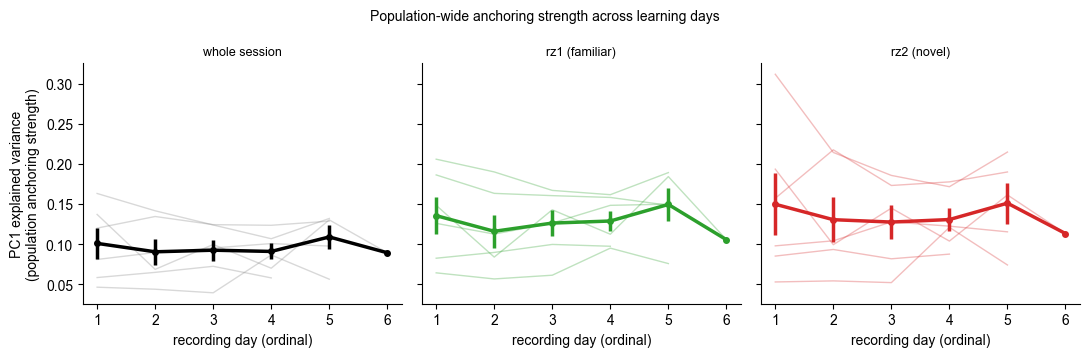

whole-session: corr(day_rank, PC1 var) = 0.04, p=0.836 (n=30 sessions)
rz1: corr(day_rank, PC1 var) = 0.09, p=0.653 (n=30 sessions)
rz2: corr(day_rank, PC1 var) = 0.07, p=0.712 (n=30 sessions)


In [24]:
"""
Population anchoring strength (PC1 explained variance) vs. learning day,
combined (whole session) and split by context. If anchoring reflects
successful use of landmarks to correct the internal map, rz2 (not yet
learned early on) should start weaker than rz1 and, if learning happens
within the window, catch up -- the direct population-level analogue of the
behavioural learning curve in Part A.
"""
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)

ax = axes[0]
for mouse, g in anchoring_df.groupby('mouse'):
    g = g.sort_values('day_rank')
    ax.plot(g['day_rank'], g['pc1_var'], alpha=0.3, linewidth=1, color='grey')
stats = anchoring_df.groupby('day_rank')['pc1_var'].agg(['mean', 'sem'])
ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color='k', linewidth=2.5, marker='o', markersize=4)
ax.set_title('whole session', fontsize=9)
ax.set_ylabel('PC1 explained variance\n(population anchoring strength)')
ax.set_xlabel('recording day (ordinal)')
ax.spines[['top', 'right']].set_visible(False)

for i, (ctx, color, label) in enumerate([('rz1', CTX1_COLOR, 'rz1 (familiar)'), ('rz2', CTX2_COLOR, 'rz2 (novel)')]):
    ax = axes[i + 1]
    col = f'pc1_var_{ctx}'
    sub = anchoring_df.dropna(subset=[col])
    for mouse, g in sub.groupby('mouse'):
        g = g.sort_values('day_rank')
        ax.plot(g['day_rank'], g[col], alpha=0.3, linewidth=1, color=color)
    stats = sub.groupby('day_rank')[col].agg(['mean', 'sem'])
    ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linewidth=2.5, marker='o', markersize=4)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('recording day (ordinal)')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Population-wide anchoring strength across learning days', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_pc1_across_days.pdf'), dpi=200, bbox_inches='tight')
plt.show()

r, p = spearmanr(anchoring_df['day_rank'], anchoring_df['pc1_var'])
print(f'whole-session: corr(day_rank, PC1 var) = {r:.2f}, p={p:.3f} (n={len(anchoring_df)} sessions)')
for ctx in ['rz1', 'rz2']:
    sub = anchoring_df.dropna(subset=[f'pc1_var_{ctx}'])
    r, p = spearmanr(sub['day_rank'], sub[f'pc1_var_{ctx}'])
    print(f'{ctx}: corr(day_rank, PC1 var) = {r:.2f}, p={p:.3f} (n={len(sub)} sessions)')

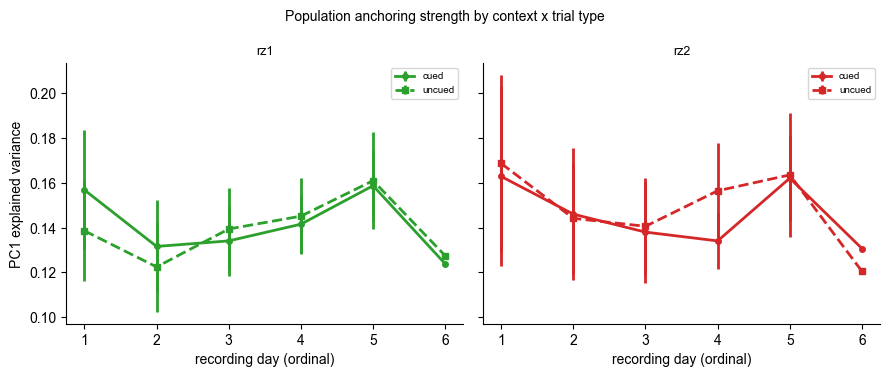

rz1-b: corr(day_rank, PC1 var) r=0.04, p=0.829 (n=30 sessions)
rz1-nb: corr(day_rank, PC1 var) r=0.17, p=0.376 (n=30 sessions)
rz2-b: corr(day_rank, PC1 var) r=0.09, p=0.625 (n=30 sessions)
rz2-nb: corr(day_rank, PC1 var) r=0.07, p=0.704 (n=30 sessions)


In [25]:
"""
Population anchoring strength split the same way as behaviour above --
context x trial type, not just context. 200-shuffle subsets (from the
batch loop above) mean these are noisier point estimates than the
whole-session number, so read trends here qualitatively alongside the
coarser context-only panel above, not as a replacement for it.
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        col = f'pc1_var_{ctx}_{ttype}'
        sub = anchoring_df.dropna(subset=[col])
        stats = sub.groupby('day_rank')[col].agg(['mean', 'sem'])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('recording day (ordinal)')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('PC1 explained variance')
fig.suptitle('Population anchoring strength by context x trial type', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_pc1_by_type_vs_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()

for ctx in ['rz1', 'rz2']:
    for ttype in ['b', 'nb']:
        col = f'pc1_var_{ctx}_{ttype}'
        sub = anchoring_df.dropna(subset=[col])
        r, p = spearmanr(sub['day_rank'], sub[col])
        print(f'{ctx}-{ttype}: corr(day_rank, PC1 var) r={r:.2f}, p={p:.3f} (n={len(sub)} sessions)')

### Anchoring dynamics, one animal at a time

Every anchoring result so far is pooled or averaged across mice. Two
direct per-animal views: what does the anchored/non-anchored raster
actually look like for each mouse's best example session, and does each
mouse's own anchoring trajectory across days track its own behavioural
trajectory -- the thing a group-level correlation can't show, since it
averages over mice going in opposite directions (e.g. M26 improving on
`rz2` while M27 never learns it).

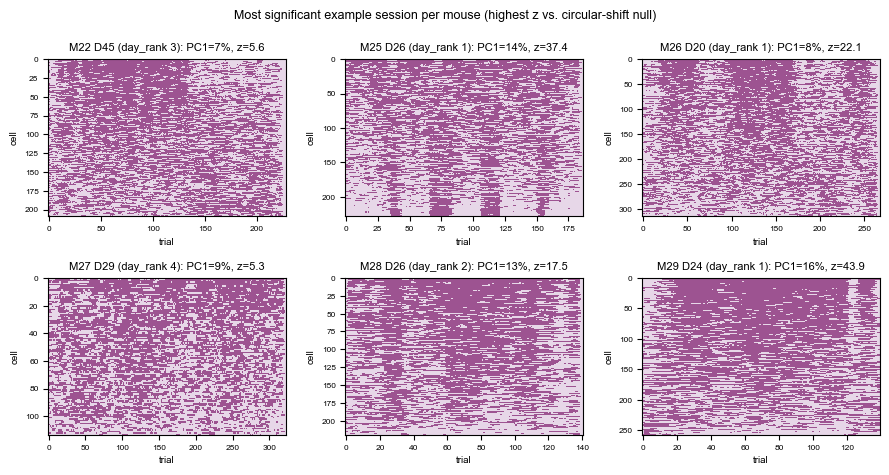

In [26]:
"""
One PC1-sorted anchoring raster per mouse -- the single most statistically
convincing session for that animal (highest z vs. its own circular-shift
null), reusing the cached label matrices from the batch loop above (no
NWB reload).
"""
from matplotlib.colors import ListedColormap, BoundaryNorm
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)

best_per_mouse = anchoring_df.loc[anchoring_df.groupby('mouse')['z'].idxmax()]
mice_list = sorted(anchoring_df['mouse'].unique())
ncols = 3
nrows = int(np.ceil(len(mice_list) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 2.4 * nrows))
axes = np.array(axes).reshape(nrows, ncols)
for i, mouse in enumerate(mice_list):
    row = best_per_mouse[best_per_mouse['mouse'] == mouse].iloc[0]
    day = int(row['day'])
    d = np.load(os.path.join(CACHE_DIR, f'{mouse}D{day}_cache.npz'), allow_pickle=True)
    M = np.nan_to_num(d['label_matrix'], nan=0.0)
    pca = PCA(n_components=1).fit(M)
    order = np.argsort(-(M @ pca.components_[0]))
    ax = axes[i // ncols, i % ncols]
    ax.imshow(M[order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    ax.set_title(f'{mouse} D{day} (day_rank {int(row.day_rank)}): '
                 f'PC1={row.pc1_var:.0%}, z={row.z:.1f}', fontsize=8)
    ax.set_xlabel('trial', fontsize=7)
    ax.set_ylabel('cell', fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(len(mice_list), nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')
fig.suptitle('Most significant example session per mouse (highest z vs. circular-shift null)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_anchoring_examples_per_mouse.pdf'), dpi=200, bbox_inches='tight')
plt.show()

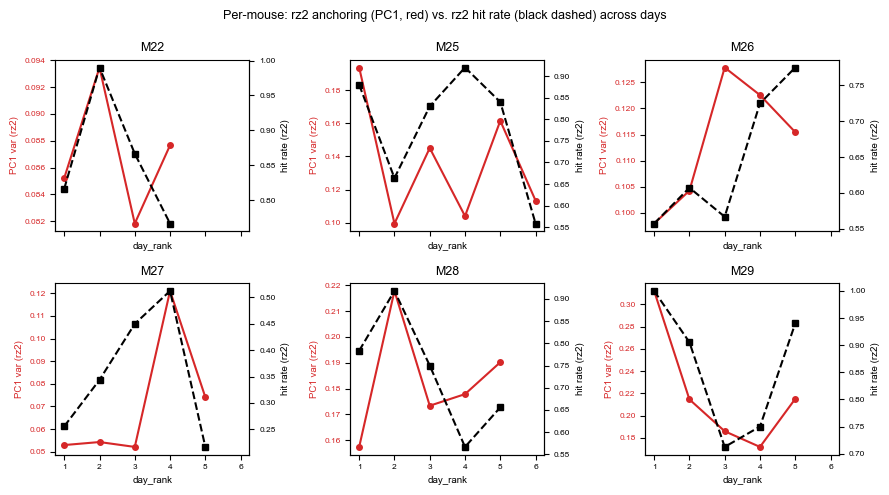

,mouse,r_anchor_rz2,p_anchor_rz2,r_hitrate_rz2,p_hitrate_rz2,n_days
0,M22,0.000000,1.000000,-0.400000,0.600000,4
1,M25,-0.142857,0.787172,-0.314286,0.544093,6
2,M26,0.600000,0.284757,0.900000,0.037386,5
3,M27,0.600000,0.284757,0.000000,1.000000,5
4,M28,0.400000,0.504632,-0.800000,0.104088,5
5,M29,-0.400000,0.504632,-0.300000,0.623838,5


In [27]:
"""
Per-mouse: rz2 anchoring strength (PC1, left axis) vs. rz2 hit rate (right
axis) across this mouse's own recording days -- the direct visual (and
quantitative) check of whether the group-level null (anchoring doesn't
track learning day) is hiding a real within-mouse relationship for the
animals that do show behavioural change.
"""
from scipy.stats import spearmanr

behaviour_rz2 = behaviour_df[behaviour_df['context'] == 'rz2'].set_index(['mouse', 'day_rank'])['hit_rate']

fig, axes = plt.subplots(2, 3, figsize=(9, 5), sharex=True)
axes = axes.ravel()
per_mouse_corr_rows = []
for i, mouse in enumerate(mice_list):
    msub = anchoring_df[anchoring_df['mouse'] == mouse].sort_values('day_rank')
    ax = axes[i]
    ax.plot(msub['day_rank'], msub['pc1_var_rz2'], color=CTX2_COLOR, marker='o', markersize=4)
    ax.set_ylabel('PC1 var (rz2)', color=CTX2_COLOR, fontsize=7)
    ax.tick_params(axis='y', labelcolor=CTX2_COLOR, labelsize=6)
    ax2 = ax.twinx()
    hr = [behaviour_rz2.get((mouse, d), np.nan) for d in msub['day_rank']]
    ax2.plot(msub['day_rank'], hr, color='k', marker='s', markersize=4, linestyle='--')
    ax2.set_ylabel('hit rate (rz2)', color='k', fontsize=7)
    ax2.tick_params(axis='y', labelcolor='k', labelsize=6)
    ax.set_title(mouse, fontsize=9)
    ax.set_xlabel('day_rank', fontsize=7)
    ax.tick_params(axis='x', labelsize=6)
    ax.spines[['top']].set_visible(False)

    valid = msub['pc1_var_rz2'].notna()
    if valid.sum() >= 3:
        r_anchor, p_anchor = spearmanr(msub.loc[valid, 'day_rank'], msub.loc[valid, 'pc1_var_rz2'])
    else:
        r_anchor, p_anchor = np.nan, np.nan
    hr_arr = np.array(hr, dtype=float)
    hr_valid = ~np.isnan(hr_arr)
    if hr_valid.sum() >= 3:
        r_hit, p_hit = spearmanr(np.array(msub['day_rank'])[hr_valid], hr_arr[hr_valid])
    else:
        r_hit, p_hit = np.nan, np.nan
    per_mouse_corr_rows.append(dict(mouse=mouse, r_anchor_rz2=r_anchor, p_anchor_rz2=p_anchor,
                                     r_hitrate_rz2=r_hit, p_hitrate_rz2=p_hit, n_days=int(valid.sum())))
for j in range(len(mice_list), len(axes)):
    axes[j].axis('off')
fig.suptitle('Per-mouse: rz2 anchoring (PC1, red) vs. rz2 hit rate (black dashed) across days', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_per_mouse_anchoring_vs_behaviour.pdf'), dpi=200, bbox_inches='tight')
plt.show()

per_mouse_corr_df = pd.DataFrame(per_mouse_corr_rows)
per_mouse_corr_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_per_mouse_anchoring_behaviour_corr.csv'), index=False)
per_mouse_corr_df

### Full anchoring rasters, every cell, every recorded day, per mouse

The example-session rasters above show one (the best) session per mouse.
Here it's every recorded day for that mouse, stacked in one figure, with
vertical lines marking where each ~20-trial context block starts -- the
direct visual version of the block-level question: does the raster look
visibly denser/cleaner (more anchored) in `rz1` blocks than `rz2` blocks,
or does that change across the session or across days? Each day is its
own recording (different cells, different PC1 sort), so rows aren't
directly comparable cell-for-cell -- what's comparable is the block
structure within a row.

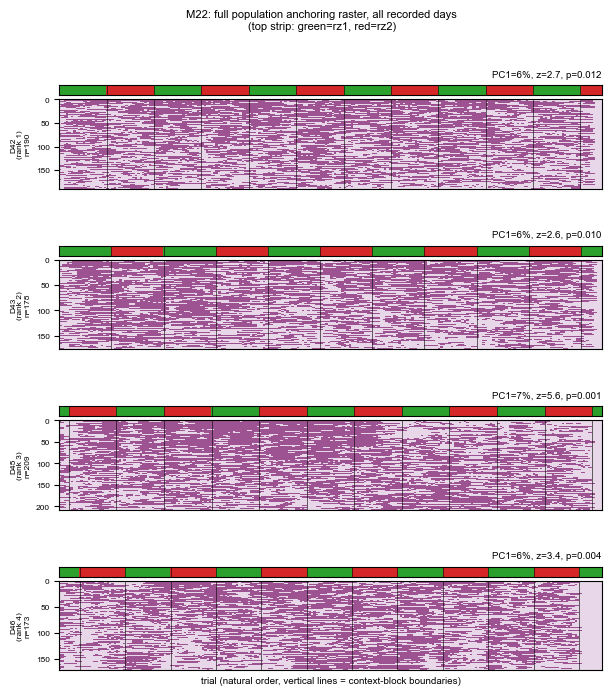

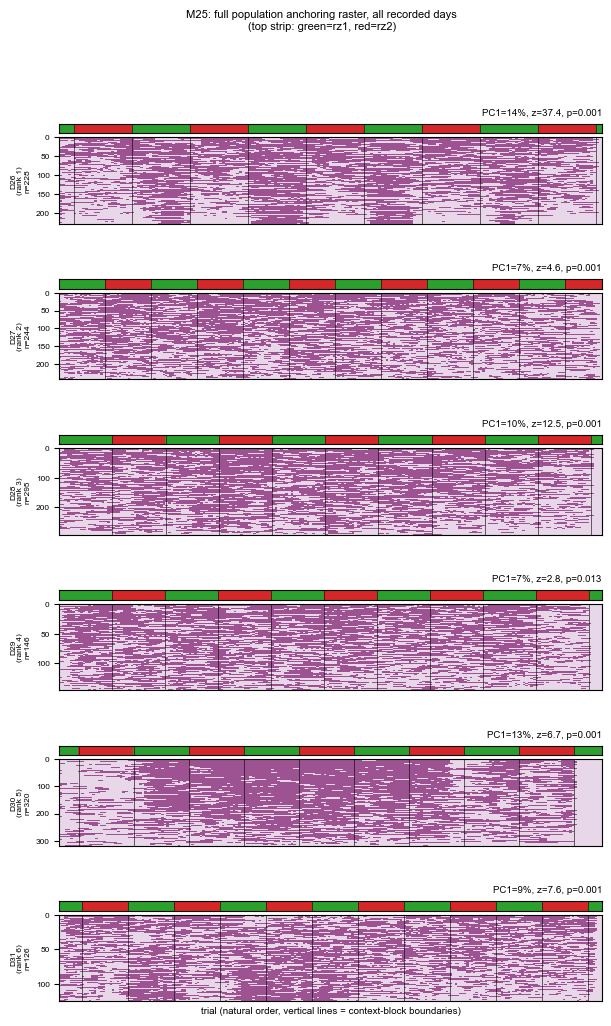

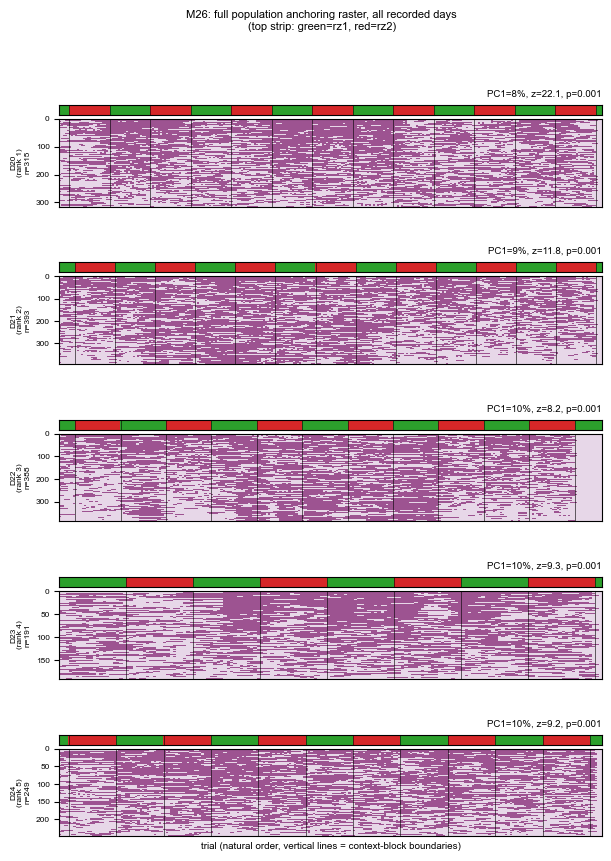

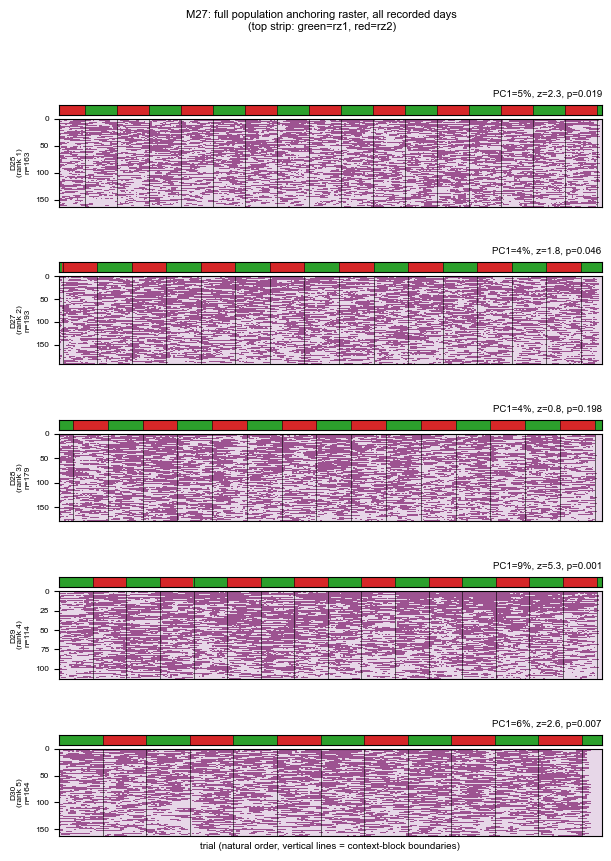

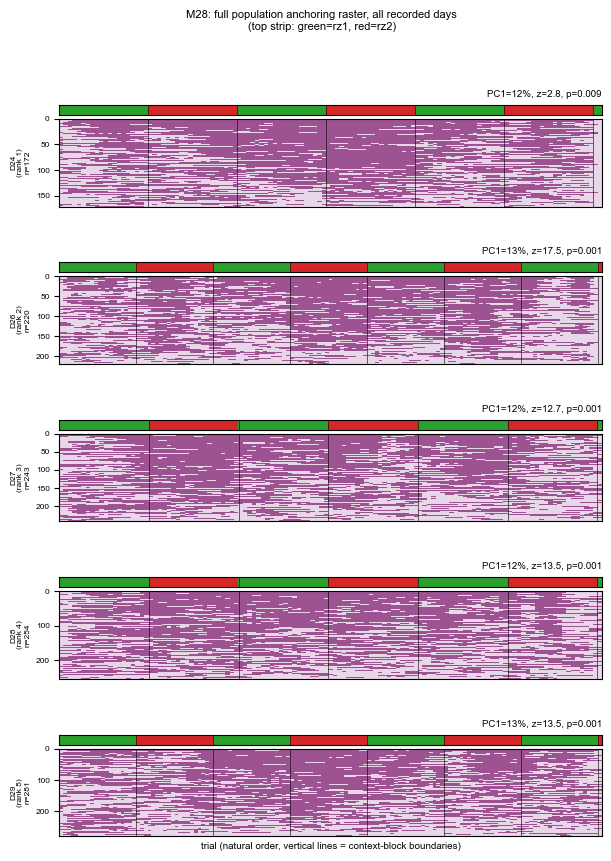

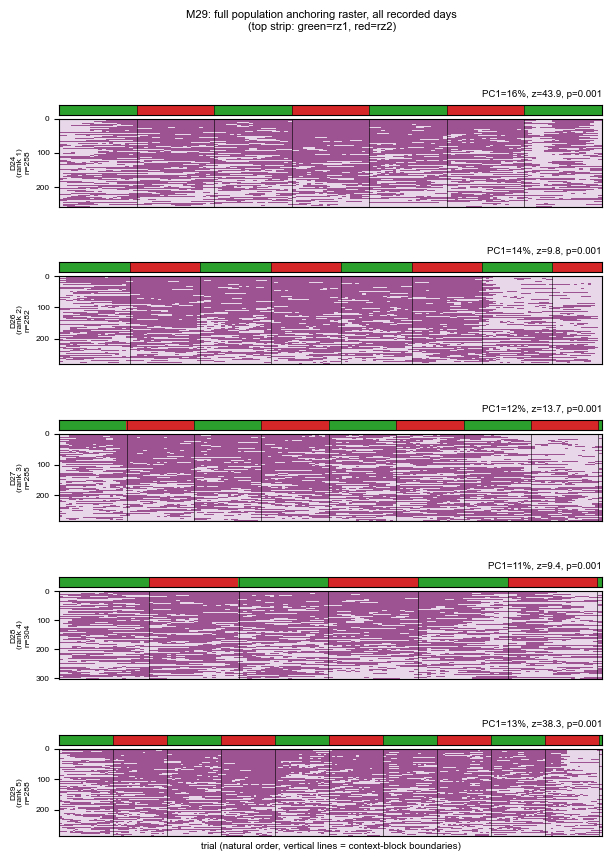

In [28]:
"""
One figure per mouse: every recorded day's PC1-sorted anchoring raster,
stacked as rows, reusing the cached label matrices from the batch loop
above (no NWB reload). A thin context strip above each raster (green=rz1,
red=rz2) plus vertical lines at every context-block boundary make within-
and cross-block anchoring density directly comparable by eye, both within
a day and across the whole recorded window for that animal. (An earlier
version tried translucent background shading instead of a strip -- it was
invisible, fully covered by the opaque raster -- fixed here.)
"""
from matplotlib.colors import ListedColormap, BoundaryNorm
TA_CMAP = ListedColormap([NONANCH_COLOR, ANCH_COLOR])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)
CTX_CMAP = ListedColormap([CTX1_COLOR, CTX2_COLOR])
CTX_NORM = BoundaryNorm([-0.5, 0.5, 1.5], CTX_CMAP.N)

mice_list = sorted(anchoring_df['mouse'].unique())
for mouse in mice_list:
    mouse_days = anchoring_df[anchoring_df['mouse'] == mouse].sort_values('day_rank')
    n_days = len(mouse_days)
    fig = plt.figure(figsize=(7, 1.9 * n_days))
    gs = fig.add_gridspec(n_days, 1, hspace=0.55)
    for ai, row in enumerate(mouse_days.itertuples()):
        day = int(row.day)
        d = np.load(os.path.join(CACHE_DIR, f'{mouse}D{day}_cache.npz'), allow_pickle=True)
        M = np.nan_to_num(d['label_matrix'], nan=0.0)
        trial_context = d['trial_context']
        pca = PCA(n_components=1).fit(M)
        order = np.argsort(-(M @ pca.components_[0]))

        block = np.zeros(len(trial_context), dtype=int)
        block[1:] = np.cumsum(trial_context[1:] != trial_context[:-1])
        block_starts = np.where(np.diff(block, prepend=block[0] - 1) != 0)[0]

        sub_gs = gs[ai].subgridspec(2, 1, height_ratios=[1, 9], hspace=0.08)
        strip_ax = fig.add_subplot(sub_gs[0])
        ax = fig.add_subplot(sub_gs[1], sharex=strip_ax)

        ctx_numeric = (trial_context == 'rz2').astype(int)
        strip_ax.imshow(ctx_numeric[None, :], aspect='auto', cmap=CTX_CMAP, norm=CTX_NORM,
                         interpolation='nearest')
        strip_ax.set_xticks([])
        strip_ax.set_yticks([])
        strip_ax.set_title(f'PC1={row.pc1_var:.0%}, z={row.z:.1f}, p={row.p:.3f}', fontsize=7, loc='right')

        ax.imshow(M[order], aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
        for b_start in block_starts[1:]:
            ax.axvline(b_start - 0.5, color='k', linewidth=0.7, alpha=0.6)
            strip_ax.axvline(b_start - 0.5, color='k', linewidth=0.7, alpha=0.6)

        ax.set_ylabel(f'D{day}\n(rank {int(row.day_rank)})\nn={M.shape[0]}', fontsize=6)
        ax.tick_params(labelsize=6)
        if ai < n_days - 1:
            ax.set_xticklabels([])
    ax.set_xlabel('trial (natural order, vertical lines = context-block boundaries)', fontsize=7)
    fig.suptitle(f'{mouse}: full population anchoring raster, all recorded days\n'
                 f'(top strip: green=rz1, red=rz2)', fontsize=8)
    plt.savefig(os.path.join(FIGPATH, f'mcvr_full_anchoring_raster_{mouse}.pdf'), dpi=200, bbox_inches='tight')
    plt.show()

In [29]:
"""
The rasters above are for eyeballing block-by-block; here's the direct
paired statistical answer to "is one context better anchored than the
other, within the same session" -- using the per-context PC1 already
computed in the batch loop (pc1_var_rz1 vs. pc1_var_rz2), paired within
session (same cells, same day, just different trial subset) so it isn't
confounded by cross-session differences in cell count or recording
quality.
"""
from scipy.stats import wilcoxon

paired = anchoring_df.dropna(subset=['pc1_var_rz1', 'pc1_var_rz2'])
stat, p = wilcoxon(paired['pc1_var_rz1'], paired['pc1_var_rz2'])
n_rz1_higher = (paired['pc1_var_rz1'] > paired['pc1_var_rz2']).sum()
print(f'rz1 vs rz2 PC1, paired within session (n={len(paired)} sessions):')
print(f'rz1 higher in {n_rz1_higher}/{len(paired)} sessions '
      f'(mean rz1-rz2 diff = {(paired["pc1_var_rz1"] - paired["pc1_var_rz2"]).mean():+.3f})')
print(f'Wilcoxon signed-rank: stat={stat:.1f}, p={p:.3f}')

rz1 vs rz2 PC1, paired within session (n=30 sessions):
rz1 higher in 13/30 sessions (mean rz1-rz2 diff = -0.007)
Wilcoxon signed-rank: stat=190.0, p=0.393


## Part C: within-day, block-by-block learning

Trials are delivered in blocks of ~20, alternating context every block --
so besides the across-day view in Parts A/B, there's a finer within-session
timescale: does hit rate (and population anchoring) change block-to-block
*within a single day*? `block_within_context` counts blocks separately per
context (the Nth time the animal has been in *this* context today, not the
Nth block overall), since blocks alternate context and the raw block index
would conflate "later in the session" with "later in this context." This is
most informative for the earliest recorded day per mouse (`day_rank==1`),
where the biggest change in context familiarity within a session would be
expected if a novel context is being learned in real time — and, per the
trial-type argument above, most likely to show up in `rz2`+`nb`
specifically, not pooled.

In [30]:
"""
Block-level hit rate, full (mouse, day, context, type, block_within_context)
resolution -- reuses the same block-extraction logic as the speed-profile
loop above, applied here to behaviour.
"""
block_rows = []
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    try:
        df = nap.load_file(f)['trials'].as_dataframe()
    except Exception:
        continue
    ctx = df['context'].values
    block = np.zeros(len(ctx), dtype=int)
    block[1:] = np.cumsum(ctx[1:] != ctx[:-1])
    df = df.copy()
    df['block_within_context'] = (
        pd.Series(block).groupby(pd.Series(ctx)).rank(method='dense').astype(int) - 1
    ).values
    for (blk, c, t), g in df.groupby(['block_within_context', 'context', 'type']):
        block_rows.append(dict(mouse=mouse, day=day, context=c, type=t, block_within_context=blk,
                                n_trials=len(g), hit_rate=(g['performance'] == 'hit').mean()))
block_df = pd.DataFrame(block_rows)
block_df['day_rank'] = block_df.groupby('mouse')['day'].rank(method='dense').astype(int)
block_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_block_level_summary.csv'), index=False)
print(f'{len(block_df)} mouse x day x context x type x block rows, '
      f'max block_within_context={block_df.block_within_context.max()}')

700 mouse x day x context x type x block rows, max block_within_context=8


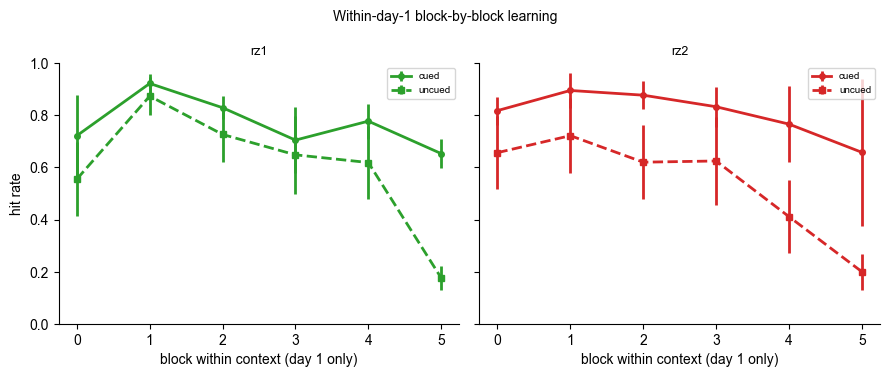

day 1, rz1-b: corr(block, hit_rate) r=-0.36, p=0.029 (n=37 mouse-block rows)
day 1, rz1-nb: corr(block, hit_rate) r=-0.49, p=0.003 (n=35 mouse-block rows)
day 1, rz2-b: corr(block, hit_rate) r=-0.29, p=0.101 (n=33 mouse-block rows)
day 1, rz2-nb: corr(block, hit_rate) r=-0.58, p=0.000 (n=33 mouse-block rows)


In [31]:
"""
Block-by-block hit rate on each mouse's first recorded day, split by
context and type -- the finest-resolution look at whether rz2 (especially
rz2-nb, the hardest condition) shows within-session improvement even
though the across-day analysis in Part A doesn't. Blocks with fewer than 3
mice contributing are dropped rather than shown as an unreliable point.
"""
day1 = block_df[block_df['day_rank'] == 1]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = day1[(day1['context'] == ctx) & (day1['type'] == ttype)]
        stats = sub.groupby('block_within_context')['hit_rate'].agg(['mean', 'sem', 'count'])
        stats = stats[stats['count'] >= 3]
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('block within context (day 1 only)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('hit rate')
fig.suptitle('Within-day-1 block-by-block learning', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_block_learning_day1.pdf'), dpi=200, bbox_inches='tight')
plt.show()

for ctx in ['rz1', 'rz2']:
    for ttype in ['b', 'nb']:
        sub = day1[(day1['context'] == ctx) & (day1['type'] == ttype)]
        if sub['block_within_context'].nunique() < 3:
            continue
        r, p = spearmanr(sub['block_within_context'], sub['hit_rate'])
        print(f'day 1, {ctx}-{ttype}: corr(block, hit_rate) r={r:.2f}, p={p:.3f} (n={len(sub)} mouse-block rows)')

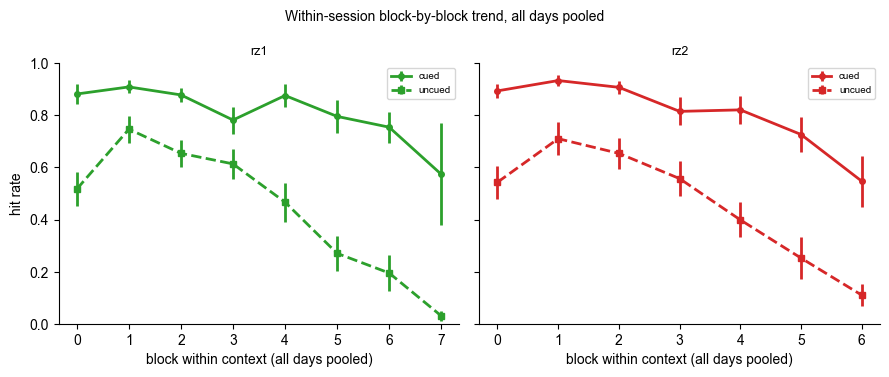

In [32]:
"""
Same block-within-context axis, pooled across all recorded days (not just
day 1) -- checks whether there's a general within-session "warm-up" effect
on every day, not just a novel-context-specific one.
"""
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, ctx, color in [(axes[0], 'rz1', CTX1_COLOR), (axes[1], 'rz2', CTX2_COLOR)]:
    for ttype, ls, marker in [('b', '-', 'o'), ('nb', '--', 's')]:
        sub = block_df[(block_df['context'] == ctx) & (block_df['type'] == ttype)]
        stats = sub.groupby('block_within_context')['hit_rate'].agg(['mean', 'sem', 'count'])
        stats = stats[stats['count'] >= 5]
        ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, linestyle=ls,
                    marker=marker, markersize=4, linewidth=2, label=TYPE_LABEL[ttype])
    ax.set_title(f'{ctx}', fontsize=9)
    ax.set_xlabel('block within context (all days pooled)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('hit rate')
fig.suptitle('Within-session block-by-block trend, all days pooled', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_block_learning_all_days.pdf'), dpi=200, bbox_inches='tight')
plt.show()

### Per-mouse: hit rate by day x block-within-context, all four conditions

The within-day decline above (Part C) and the flat-to-null across-day
trend (Part A) are two slices of the same underlying `block_df` table.
Putting day (y) and block-within-context (x) on the same axes, per mouse
and per context x type condition, makes both visible together and is the
most direct way to check whether the within-day drop looks like satiety/
engagement (should reset every day, same pattern day after day) rather
than a learning effect (should shrink or disappear on later days).

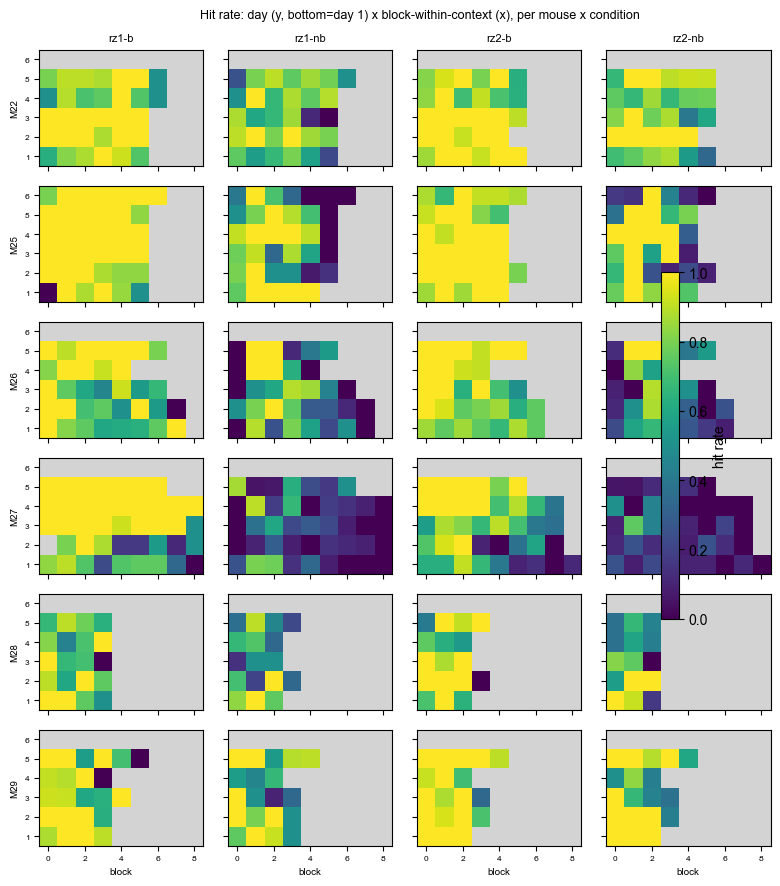

In [33]:
"""
One heatmap per mouse x condition: day_rank (y, day 1 at the bottom) x
block_within_context (x) -> hit rate. Missing day x block combinations
(a day with fewer blocks than another) are left blank rather than
interpolated.
"""
conditions = [('rz1', 'b'), ('rz1', 'nb'), ('rz2', 'b'), ('rz2', 'nb')]
mice_list = sorted(block_df['mouse'].unique())
max_block = int(block_df['block_within_context'].max())
max_day = int(block_df['day_rank'].max())

cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('lightgrey')

fig, axes = plt.subplots(len(mice_list), 4, figsize=(8.5, 1.5 * len(mice_list)),
                          sharex=True, sharey=True)
im = None
for mi, mouse in enumerate(mice_list):
    msub = block_df[block_df['mouse'] == mouse]
    for ci, (ctx, ttype) in enumerate(conditions):
        ax = axes[mi, ci]
        csub = msub[(msub['context'] == ctx) & (msub['type'] == ttype)]
        pivot = csub.pivot_table(index='day_rank', columns='block_within_context', values='hit_rate')
        pivot = pivot.reindex(index=range(1, max_day + 1), columns=range(0, max_block + 1))
        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, vmin=0, vmax=1, origin='lower')
        if mi == 0:
            ax.set_title(f'{ctx}-{ttype}', fontsize=8)
        if ci == 0:
            ax.set_ylabel(mouse, fontsize=7)
            ax.set_yticks(range(max_day))
            ax.set_yticklabels(range(1, max_day + 1), fontsize=6)
        ax.tick_params(labelsize=6)
        if mi == len(mice_list) - 1:
            ax.set_xlabel('block', fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.5, label='hit rate', pad=0.015)
fig.suptitle('Hit rate: day (y, bottom=day 1) x block-within-context (x), per mouse x condition',
             fontsize=9)
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig(os.path.join(FIGPATH, 'mcvr_hitrate_day_by_block_per_mouse.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [34]:
"""
Does the within-day block decline itself change across recording days?
Pooled across conditions and mice per day_rank -- a fading decline would
mean mice are learning something (how to sustain engagement across a full
session), just not what Part A tested for (where the reward is).
"""
from scipy.stats import spearmanr

print('within-day block decline, pooled across conditions/mice, by day_rank:')
for day in sorted(block_df['day_rank'].unique()):
    sub = block_df[block_df['day_rank'] == day]
    if sub['block_within_context'].nunique() < 3:
        continue
    r, p = spearmanr(sub['block_within_context'], sub['hit_rate'])
    print(f'day_rank {day}: corr(block, hit_rate) r={r:.2f}, p={p:.3f} (n={len(sub)})')

within-day block decline, pooled across conditions/mice, by day_rank:
day_rank 1: corr(block, hit_rate) r=-0.42, p=0.000 (n=138)
day_rank 2: corr(block, hit_rate) r=-0.49, p=0.000 (n=140)
day_rank 3: corr(block, hit_rate) r=-0.28, p=0.001 (n=136)
day_rank 4: corr(block, hit_rate) r=-0.12, p=0.183 (n=125)
day_rank 5: corr(block, hit_rate) r=-0.12, p=0.159 (n=135)
day_rank 6: corr(block, hit_rate) r=-0.13, p=0.523 (n=26)


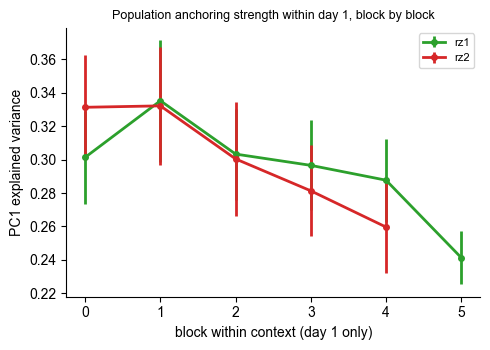

In [35]:
"""
Population anchoring strength at block resolution -- reusing the label
matrices already cached by Part B's batch run (block boundaries come
directly from the cached `trial_context` array, no NWB reloading needed).
Each block is only ~20 trials, at the low end of what the classifier needs
(`min_valid_trials=6` per cell), so this is more exploratory/noisier than
the session-level numbers and is not split by trial type (would leave
~10 trials per point) -- context only.
"""
block_anchoring_rows = []
for cache_path in sorted(glob.glob(os.path.join(CACHE_DIR, '*_cache.npz'))):
    fname = os.path.basename(cache_path)
    mm = re.match(r'(M\d+)D(\d+)_cache\.npz', fname)
    mouse, day = mm.group(1), int(mm.group(2))
    d = np.load(cache_path, allow_pickle=True)
    M = np.nan_to_num(d['label_matrix'], nan=0.0)
    trial_context = d['trial_context']
    block = np.zeros(len(trial_context), dtype=int)
    block[1:] = np.cumsum(trial_context[1:] != trial_context[:-1])
    block_within_context = (
        pd.Series(block).groupby(pd.Series(trial_context)).rank(method='dense').astype(int) - 1
    ).values
    for blk in np.unique(block):
        cols = np.where(block == blk)[0]
        if len(cols) < 10:
            continue
        pc1 = pc1_explained_var(M[:, cols])
        block_anchoring_rows.append(dict(mouse=mouse, day=day, context=str(trial_context[cols[0]]),
                                          block_within_context=int(block_within_context[cols[0]]), pc1_var=pc1))
block_anchoring_df = pd.DataFrame(block_anchoring_rows)
block_anchoring_df['day_rank'] = block_anchoring_df.groupby('mouse')['day'].rank(method='dense').astype(int)
block_anchoring_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_block_anchoring_summary.csv'), index=False)

day1_anchoring = block_anchoring_df[block_anchoring_df['day_rank'] == 1]
fig, ax = plt.subplots(figsize=(5, 3.6))
for ctx, color in [('rz1', CTX1_COLOR), ('rz2', CTX2_COLOR)]:
    sub = day1_anchoring[day1_anchoring['context'] == ctx]
    stats = sub.groupby('block_within_context')['pc1_var'].agg(['mean', 'sem', 'count'])
    stats = stats[stats['count'] >= 3]
    ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'], color=color, marker='o',
                markersize=4, linewidth=2, label=ctx)
ax.set_xlabel('block within context (day 1 only)')
ax.set_ylabel('PC1 explained variance')
ax.set_title('Population anchoring strength within day 1, block by block', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_block_anchoring_day1.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Part D: how, and when, is `rz2` actually learned?

Everything above tests for a *day-level* learning trend and finds none.
But day is an arbitrary unit -- the animal's actual learning process, if
any, operates on individual exposures to the new context, and `rz2`
recurs several times within day 1 alone (blocks alternate context, so day
1 already contains ~5-6 separate `rz2` blocks). Re-indexing every `rz2`
trial by **the Nth time that mouse has ever encountered `rz2`** (counted
continuously across the whole recording, not reset each day) turns the
question into a proper exposure-indexed learning curve, and lets three
specific hypotheses be told apart directly:

- **Zero-shot**: performance on exposure #1 is already indistinguishable
  from the animal's long-run `rz1` performance -- no learning needed at all,
  most plausibly via generalization from the already-mastered `rz1` task
  structure.
- **One-shot**: a sharp step-change within the first handful of exposures,
  then a stable plateau.
- **Gradual**: a smooth improvement extending over many exposures (or
  days).

Two outcome measures, since they can behave differently: **hit rate**
(binary, task-level success) and **stop-position error** (continuous, cm
off the true reward-zone location -- a much more sensitive readout of
*how* the trial was executed, not just whether it worked out). `rz1`
exposures are indexed and plotted the same way as a no-learning-needed
control, so any `rz2`-specific pattern isn't just a generic session-position
effect (the within-day satiety decline already established in Part C).

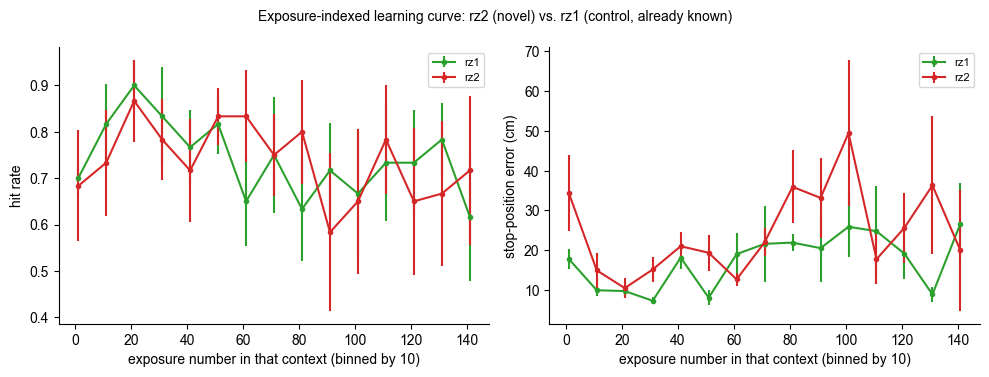

In [36]:
"""
Exposure number = the Nth trial that mouse has ever had in that context,
counted continuously across the whole recording (not reset each day) --
uses trial_idx, which preserves true chronological order within a mouse
(sessions loaded in day order, trials within a session in natural order).
Binned into groups of 10 for smoother rate estimates, aggregated to
mouse x context x bin FIRST (matching the fix above -- pooling raw trials
across mice with unequal counts risks exactly the artifact that inflated
the earlier rz2-b day-trend before it was corrected).
"""
exposure_df = speed_trial_df.sort_values(['mouse', 'trial_idx']).copy()
exposure_df['hit'] = (exposure_df['performance'] == 'hit').astype(float)
exposure_df['rz_exposure_num'] = exposure_df.groupby(['mouse', 'context']).cumcount() + 1

EXPOSURE_BIN = 10
exposure_df['exposure_bin'] = ((exposure_df['rz_exposure_num'] - 1) // EXPOSURE_BIN) * EXPOSURE_BIN + 1

per_mouse_bin = (exposure_df.groupby(['mouse', 'context', 'exposure_bin'])[['hit', 'stop_position_error']]
                  .mean().reset_index())
pooled_bin = (per_mouse_bin.groupby(['context', 'exposure_bin'])[['hit', 'stop_position_error']]
              .agg(['mean', 'sem']).reset_index())
pooled_bin.columns = ['context', 'exposure_bin', 'hit_mean', 'hit_sem', 'stoperr_mean', 'stoperr_sem']

MAX_BIN_TO_PLOT = 150  # first ~15 blocks per context -- plenty to see the shape, avoids thinning-tail noise
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, metric_mean, metric_sem, ylabel in [
    (axes[0], 'hit_mean', 'hit_sem', 'hit rate'),
    (axes[1], 'stoperr_mean', 'stoperr_sem', 'stop-position error (cm)'),
]:
    for ctx, color in [('rz1', CTX1_COLOR), ('rz2', CTX2_COLOR)]:
        sub = pooled_bin[(pooled_bin['context'] == ctx) & (pooled_bin['exposure_bin'] <= MAX_BIN_TO_PLOT)]
        ax.errorbar(sub['exposure_bin'], sub[metric_mean], yerr=sub[metric_sem], color=color,
                    marker='o', markersize=3, linewidth=1.5, label=ctx)
    ax.set_xlabel('exposure number in that context (binned by 10)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Exposure-indexed learning curve: rz2 (novel) vs. rz1 (control, already known)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_exposure_learning_curve.pdf'), dpi=200, bbox_inches='tight')
plt.show()

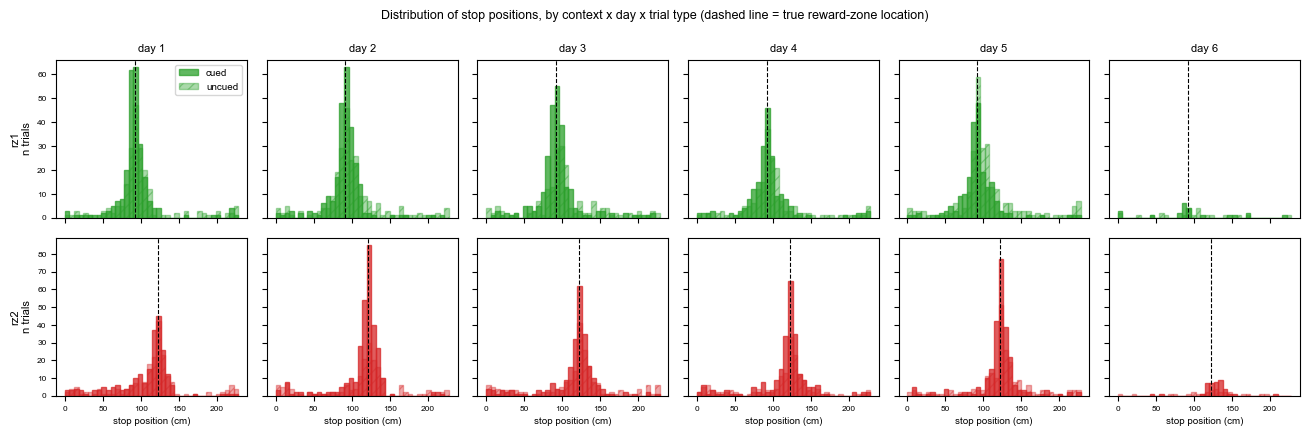

In [37]:
"""
The mean-trend curves above hide distribution shape -- e.g. a mouse that
sometimes stops at the *old*, familiar rz1 location out of habit while
actually in rz2 would show up as a second mode near 92cm, not just a wider
spread. Small-multiple histograms: rows = context, columns = recording day
(day_rank), b (solid) and nb (hatched) overlaid per panel, vertical dashed
line = known reward-zone location for that context. Pooled across mice
(consistent with the rest of this notebook's distribution-style plots) --
only trials with a detected stop are included, same convention as
everywhere else.
"""
stop_df = speed_trial_df.dropna(subset=['stop_position']).copy()
max_day = int(stop_df['day_rank'].max())
STOP_BINS = np.arange(0, TL + BS, BS * 3)

fig, axes = plt.subplots(2, max_day, figsize=(2.2 * max_day, 4.4), sharex=True, sharey='row')
for ri, (ctx, color, rz) in enumerate([('rz1', CTX1_COLOR, RZ_LOCATION['rz1']),
                                        ('rz2', CTX2_COLOR, RZ_LOCATION['rz2'])]):
    for day in range(1, max_day + 1):
        ax = axes[ri, day - 1]
        day_ctx = stop_df[(stop_df['context'] == ctx) & (stop_df['day_rank'] == day)]
        for ttype, hatch, alpha in [('b', None, 0.75), ('nb', '///', 0.4)]:
            sub = day_ctx[day_ctx['type'] == ttype]
            ax.hist(sub['stop_position'], bins=STOP_BINS, color=color, alpha=alpha,
                    hatch=hatch, edgecolor=color, label=TYPE_LABEL[ttype] if ri == 0 and day == 1 else None)
        ax.axvline(rz, color='k', linewidth=0.8, linestyle='--')
        if ri == 0:
            ax.set_title(f'day {day}', fontsize=8)
        if day == 1:
            ax.set_ylabel(f'{ctx}\nn trials', fontsize=8)
        ax.tick_params(labelsize=6)
        if ri == 1:
            ax.set_xlabel('stop position (cm)', fontsize=7)
axes[0, 0].legend(fontsize=7)
fig.suptitle('Distribution of stop positions, by context x day x trial type '
             '(dashed line = true reward-zone location)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_stop_position_distributions.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [38]:
"""
Zero-shot test: is the very first block of rz2 exposure (trials 1-10 ever)
already at the animal's own rz1 level? Paired per mouse (n=6) against that
mouse's own long-run rz1 mean, so it isn't confounded by cross-mouse
differences in overall task competence.
"""
from scipy.stats import wilcoxon

rz1_grand = exposure_df[exposure_df['context'] == 'rz1'].groupby('mouse')[['hit', 'stop_position_error']].mean()
rz2_first10 = (exposure_df[(exposure_df['context'] == 'rz2') & (exposure_df['rz_exposure_num'] <= 10)]
               .groupby('mouse')[['hit', 'stop_position_error']].mean())

print('literal first-ever rz2 trial per mouse (performance label):')
first_trial = exposure_df[(exposure_df['context'] == 'rz2') & (exposure_df['rz_exposure_num'] == 1)]
print(first_trial[['mouse', 'day_rank', 'performance']].to_string(index=False))
print()

for metric in ['hit', 'stop_position_error']:
    paired = pd.concat([rz1_grand[metric].rename('rz1_longrun'),
                         rz2_first10[metric].rename('rz2_first10exposures')], axis=1).dropna()
    stat, p = wilcoxon(paired['rz1_longrun'], paired['rz2_first10exposures'])
    print(f'--- {metric}: rz1 long-run vs rz2 first-10-exposures (n={len(paired)} mice) ---')
    print(paired)
    print(f'wilcoxon: stat={stat}, p={p:.4f}\n')

literal first-ever rz2 trial per mouse (performance label):
mouse  day_rank performance
  M22         1         hit
  M25         1         try
  M26         1         hit
  M27         1         try
  M28         1        slow
  M29         1         hit

--- hit: rz1 long-run vs rz2 first-10-exposures (n=6 mice) ---
       rz1_longrun  rz2_first10exposures
mouse                                   
M22       0.813620                   0.7
M25       0.820350                   0.8
M26       0.669596                   0.2
M27       0.499343                   0.5
M28       0.683140                   0.9
M29       0.799007                   1.0
wilcoxon: stat=10.0, p=1.0000

--- stop_position_error: rz1 long-run vs rz2 first-10-exposures (n=6 mice) ---
       rz1_longrun  rz2_first10exposures
mouse                                   
M22      16.781579             59.333333
M25      19.396624             15.875000
M26      15.564159             65.666667
M27      33.804124             36.250

In [39]:
"""
One-shot-vs-gradual test for stop-position precision specifically (the
metric with the cleanest signal): does it keep improving smoothly across
many exposures (gradual), or jump once early and then plateau (one-shot)?
Three windows per mouse: exposures 1-10, 11-20, 21-60.
"""
rz2 = exposure_df[exposure_df['context'] == 'rz2']
w1 = rz2[rz2['rz_exposure_num'].between(1, 10)].groupby('mouse')['stop_position_error'].mean()
w2 = rz2[rz2['rz_exposure_num'].between(11, 20)].groupby('mouse')['stop_position_error'].mean()
w3 = rz2[rz2['rz_exposure_num'].between(21, 60)].groupby('mouse')['stop_position_error'].mean()
windows = pd.concat([w1.rename('exposures_1-10'), w2.rename('exposures_11-20'),
                      w3.rename('exposures_21-60')], axis=1).dropna()
print('stop-position error (cm) by exposure window, per mouse:')
print(windows)
print()

s, p = wilcoxon(windows['exposures_1-10'], windows['exposures_11-20'])
print(f'exposures 1-10 vs 11-20 (the "first block vs second block" test): stat={s}, p={p:.4f}, '
      f'n_improving={int((windows["exposures_1-10"] > windows["exposures_11-20"]).sum())}/{len(windows)} mice')
s, p = wilcoxon(windows['exposures_11-20'], windows['exposures_21-60'])
print(f'exposures 11-20 vs 21-60 (does it keep improving, or plateau?): stat={s}, p={p:.4f}, '
      f'n_improving={int((windows["exposures_11-20"] > windows["exposures_21-60"]).sum())}/{len(windows)} mice')

stop-position error (cm) by exposure window, per mouse:
       exposures_1-10  exposures_11-20  exposures_21-60
mouse                                                  
M22         59.333333        14.000000        17.333333
M25         15.875000        16.000000        22.100000
M26         65.666667        15.166667        20.645161
M27         36.250000        34.000000        14.250000
M28         20.300000         6.400000        20.810811
M29          8.900000         4.000000         5.100000

exposures 1-10 vs 11-20 (the "first block vs second block" test): stat=1.0, p=0.0625, n_improving=5/6 mice
exposures 11-20 vs 21-60 (does it keep improving, or plateau?): stat=6.0, p=0.4375, n_improving=1/6 mice


**Reading the three tests together**: hit rate on the very first-ever
`rz2` trial is a coin flip across mice (3/6 hit it immediately), but by
the first 10 exposures hit rate is already statistically indistinguishable
from that mouse's own long-run `rz1` rate -- consistent with **zero-shot**
task-level competence for most animals (the clear exception being whichever
mouse struggles early, worth checking against the per-mouse table above).
Stop-position error tells a different, complementary story: it starts
elevated in the very first block and drops sharply by the second block
(exposures 1-10 vs 11-20), then **plateaus** with no further improvement
(11-20 vs 21-60) -- a **one-shot** recalibration of *where exactly* to stop,
not a slow multi-day refinement, and not something the binary hit-rate
measure alone would have revealed. Neither pattern matches the original
day-level "gradual learning over ~5 days" expectation the notebook opened
with -- both operate on a much faster timescale, within the first exposure
block.

### Does this hold separately for cued and uncued trials?

Everything in Part D so far pooled over trial type. `b` (reward zone
signaled) and `nb` (reward zone not signaled, memory-only) are different
enough conditions that a pooled "zero-shot" result could easily be an
average of two very different underlying processes -- e.g. fast
signal-guided calibration on `b` masking slower, harder memory-based
learning on `nb`. Re-running the same three
tests with a **type-specific exposure counter** (the Nth `rz2-b` trial
ever, and separately the Nth `rz2-nb` trial ever, since `b`/`nb` are
randomly interleaved within blocks rather than themselves blocked)
checks this directly.

In [40]:
"""
Same zero-shot test as above (first-10-exposures vs. own rz1 long-run
rate), computed separately per trial type with its own type-specific
exposure counter.
"""
type_exposure_df = speed_trial_df.sort_values(['mouse', 'trial_idx']).copy()
type_exposure_df['hit'] = (type_exposure_df['performance'] == 'hit').astype(float)
type_exposure_df['type_exposure_num'] = (
    type_exposure_df.groupby(['mouse', 'context', 'type']).cumcount() + 1
)

for ttype in ['b', 'nb']:
    print(f'=========== type = {ttype} ===========')
    first_trial = type_exposure_df[(type_exposure_df['context'] == 'rz2') & (type_exposure_df['type'] == ttype)
                                    & (type_exposure_df['type_exposure_num'] == 1)]
    print(f'literal first-ever rz2-{ttype} trial per mouse:')
    print(first_trial[['mouse', 'day_rank', 'performance']].to_string(index=False))

    rz1_grand = (type_exposure_df[(type_exposure_df['context'] == 'rz1') & (type_exposure_df['type'] == ttype)]
                 .groupby('mouse')[['hit', 'stop_position_error']].mean())
    rz2_first10 = (type_exposure_df[(type_exposure_df['context'] == 'rz2') & (type_exposure_df['type'] == ttype)
                                     & (type_exposure_df['type_exposure_num'] <= 10)]
                   .groupby('mouse')[['hit', 'stop_position_error']].mean())
    for metric in ['hit', 'stop_position_error']:
        paired = pd.concat([rz1_grand[metric].rename('rz1_longrun'),
                             rz2_first10[metric].rename('rz2_first10')], axis=1).dropna()
        stat, p = wilcoxon(paired['rz1_longrun'], paired['rz2_first10'])
        print(f'--- {metric} (n={len(paired)} mice): wilcoxon rz1 vs rz2-first10, stat={stat}, p={p:.4f} ---')
    print()

=========== type = b ===========
literal first-ever rz2-b trial per mouse:
mouse  day_rank performance
  M22         1         hit
  M25         1         try
  M26         1         hit
  M27         1         try
  M28         1        slow
  M29         1         hit
--- hit (n=6 mice): wilcoxon rz1 vs rz2-first10, stat=10.0, p=1.0000 ---
--- stop_position_error (n=6 mice): wilcoxon rz1 vs rz2-first10, stat=4.0, p=0.2188 ---

=========== type = nb ===========
literal first-ever rz2-nb trial per mouse:
mouse  day_rank performance
  M22         1         hit
  M25         1         hit
  M26         1         run
  M27         1         run
  M28         1         hit
  M29         1         hit
--- hit (n=6 mice): wilcoxon rz1 vs rz2-first10, stat=10.0, p=1.0000 ---
--- stop_position_error (n=6 mice): wilcoxon rz1 vs rz2-first10, stat=6.0, p=0.4375 ---



In [41]:
"""
Same one-shot-vs-gradual precision window test as above (exposures 1-10 vs
11-20 vs 21-60), computed separately per type.
"""
for ttype in ['b', 'nb']:
    print(f'=========== type = {ttype}: precision window test ===========')
    rz2_t = type_exposure_df[(type_exposure_df['context'] == 'rz2') & (type_exposure_df['type'] == ttype)]
    w1 = rz2_t[rz2_t['type_exposure_num'].between(1, 10)].groupby('mouse')['stop_position_error'].mean()
    w2 = rz2_t[rz2_t['type_exposure_num'].between(11, 20)].groupby('mouse')['stop_position_error'].mean()
    w3 = rz2_t[rz2_t['type_exposure_num'].between(21, 60)].groupby('mouse')['stop_position_error'].mean()
    windows = pd.concat([w1.rename('exp1-10'), w2.rename('exp11-20'), w3.rename('exp21-60')], axis=1).dropna()
    print(windows)
    s, p = wilcoxon(windows['exp1-10'], windows['exp11-20'])
    print(f'exp1-10 vs exp11-20: stat={s}, p={p:.4f}, '
          f'n_improving={int((windows["exp1-10"] > windows["exp11-20"]).sum())}/{len(windows)}')
    s, p = wilcoxon(windows['exp11-20'], windows['exp21-60'])
    print(f'exp11-20 vs exp21-60: stat={s}, p={p:.4f}, '
          f'n_improving={int((windows["exp11-20"] > windows["exp21-60"]).sum())}/{len(windows)}')
    print()

=========== type = b: precision window test ===========
         exp1-10   exp11-20   exp21-60
mouse                                 
M22    40.000000  20.000000  24.636364
M25    20.000000  18.600000  28.975000
M26    30.714286  18.000000  28.032258
M27    35.428571  15.666667  28.875000
M28    20.200000  15.111111  14.742857
M29     8.900000   6.400000   8.717949
exp1-10 vs exp11-20: stat=0.0, p=0.0312, n_improving=6/6
exp11-20 vs exp21-60: stat=1.0, p=0.0625, n_improving=1/6

=========== type = nb: precision window test ===========
         exp1-10  exp11-20   exp21-60
mouse                                
M22     6.000000      13.0  35.875000
M25    12.125000      11.8  26.358974
M26    44.000000      11.5  54.565217
M27    36.666667       8.0  57.400000
M28    14.300000      19.2  15.000000
M29     5.400000       3.6  11.631579
exp1-10 vs exp11-20: stat=7.0, p=0.5625, n_improving=4/6
exp11-20 vs exp21-60: stat=1.0, p=0.0625, n_improving=1/6



**The pooled picture hides a real asymmetry.** Hit rate is zero-shot for
both types (p=1.0 either way) -- unsurprising, since that result was
already close to a ceiling effect. Stop-position precision is where types
diverge sharply: on **cued** trials, the one-shot calibration is clean
and strong -- **6/6 mice** improve from exposures 1-10 to 11-20 (p=0.031,
the maximum significance n=6 permits), then a stable plateau. On
**uncued** trials, that early jump is weak and inconsistent (4/6
mice, p=0.56) -- and precision often gets *worse*, not better, from
exposures 11-20 to 21-60 (5/6 mice, p=0.063), the opposite of a learning
signal. This makes sense mechanistically: a signaled reward zone gives
an immediate, reliable landmark to calibrate a stop against, enabling
fast one-shot recalibration; without a signal, the animal is relying on
distance run through the always-visible context wall pattern plus
memory, which doesn't offer the same fast error signal to correct against -- and may be more vulnerable to the same
satiety/engagement decline documented in Part C. So "one-shot precision
calibration" is really a **cued-trial-specific** finding, not a
general property of how `rz2` is learned -- the uncued condition
still shows no clean evidence of learning on *any* timescale tested in
this notebook.

## Part E: does the population's spatial code generalize across contexts?

Everything above asks whether *behaviour* and *anchoring* track learning.
A different, more direct neural question: train a position decoder using
only `rz1` trials, then test it on `rz2` trials, unseen during training.
If the population uses a shared, context-invariant code for "distance
along the track," the decoder should transfer well; if the two contexts
are represented by genuinely distinct population codes (classic
hippocampal-formation remapping), it should fail -- and *how* it fails
(random vs. systematically biased) is itself informative. Run across every session with enough rz1/rz2 trials and cells (30/31
sessions), with one session shown in full illustrative detail --
chosen from the batch below for its combination of strong within-context
decoding and a large, clear cross-context gap, not cherry-picked after
the fact.

**Method**: a standard Bayesian (Poisson) population-vector decoder --
per-cell position tuning curves (`nap.compute_1d_tuning_curves`, the same
machinery used throughout this notebook) trained on half of `rz1`'s
trials only, then MAP-decoded in 250ms windows against (a) the other half
of `rz1` (held-out, within-context baseline -- what's the best this
population/session can do at all) and (b) every `rz2` trial (the actual
cross-context test).

In [42]:
"""
Same decoder pipeline as the single-session version below, run across
every session -- within-context (held-out rz1), cross-context (rz2), and
a shuffle-null, per session. Used both as the primary (population-level)
evidence for cross-context degradation, and to pick the best single
session to show in illustrative detail.
"""
WIN = 0.25  # s, decoding window
n_bins = int(TL / BS)
pos_bin_centers = (np.arange(n_bins) + 0.5) * BS

def circ_dist(a, b, tl=TL):
    d = np.abs(a - b) % tl
    return np.minimum(d, tl - d)

def make_ep(trial_subset):
    return nap.IntervalSet(start=trial_subset['start'].values, end=trial_subset['end'].values)

decoder_batch_rows = []
t0 = time.time()
for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    b_mouse, b_day = m.group(1), int(m.group(2))
    b_data = nap.load_file(f)
    b_units = curate_clusters(b_data['units'])
    b_trials = b_data['trials'].as_dataframe()
    b_rz1 = b_trials[b_trials['context'] == 'rz1']
    b_rz2 = b_trials[b_trials['context'] == 'rz2']
    if len(b_units) < 5 or len(b_rz1) < 20 or len(b_rz2) < 20:
        continue

    b_rz1_train, b_rz1_test = b_rz1.iloc[0::2], b_rz1.iloc[1::2]
    b_tc = np.array(nap.compute_1d_tuning_curves(b_units, b_data['P'], nb_bins=n_bins,
                                                   ep=make_ep(b_rz1_train), minmax=[0, TL]))
    b_rate = b_tc.T + 1e-3
    b_log_rate = np.log(b_rate)

    def b_decode(test_ep):
        counts = b_units.count(WIN, ep=test_ep)
        counts_arr = np.array(counts.values)
        t_centers = np.array(counts.index)
        Pt, Pv = np.array(b_data['P'].index), np.array(b_data['P'].values)
        true_pos = np.interp(t_centers, Pt, Pv)
        log_post = counts_arr @ b_log_rate - WIN * b_rate.sum(axis=0)[None, :]
        return true_pos, pos_bin_centers[np.argmax(log_post, axis=1)]

    b_true_w, b_dec_w = b_decode(make_ep(b_rz1_test))
    b_true_c, b_dec_c = b_decode(make_ep(b_rz2))

    b_rng = np.random.default_rng(0)
    b_shuffle_errs = []
    for _ in range(10):
        perm = b_rng.permutation(n_bins)
        counts = b_units.count(WIN, ep=make_ep(b_rz2))
        counts_arr = np.array(counts.values)
        log_post = counts_arr @ b_log_rate[:, perm] - WIN * b_rate[:, perm].sum(axis=0)[None, :]
        dec_shuf = pos_bin_centers[np.argmax(log_post, axis=1)]
        b_shuffle_errs.append(np.median(circ_dist(dec_shuf, b_true_c)))

    err_w = np.median(circ_dist(b_dec_w, b_true_w))
    err_c = np.median(circ_dist(b_dec_c, b_true_c))
    err_s = np.mean(b_shuffle_errs)
    decoder_batch_rows.append(dict(mouse=b_mouse, day=b_day, n_cells=len(b_units),
                                    n_rz1=len(b_rz1), n_rz2=len(b_rz2),
                                    err_within=err_w, err_cross=err_c, err_shuffle=err_s,
                                    gen_index=(err_s - err_c) / (err_s - err_w) if err_s != err_w else np.nan))

decoder_batch_df = pd.DataFrame(decoder_batch_rows)
decoder_batch_df['fold'] = decoder_batch_df['err_cross'] / decoder_batch_df['err_within']
decoder_batch_df.to_csv(os.path.join(CACHE_DIR, 'mcvr_decoder_batch_summary.csv'), index=False)
print(f'done in {time.time()-t0:.0f}s, {len(decoder_batch_df)}/{len(SESSION_FILES)} sessions succeeded')

from scipy.stats import wilcoxon
stat, p = wilcoxon(decoder_batch_df['err_within'], decoder_batch_df['err_cross'])
print(f'paired wilcoxon, within vs. cross-context error (n={len(decoder_batch_df)} sessions): stat={stat}, p={p:.2e}')
print(f'{(decoder_batch_df.fold > 1).sum()}/{len(decoder_batch_df)} sessions show cross-context error worse than within-context')
print(f'median within={decoder_batch_df.err_within.median():.1f}cm, cross={decoder_batch_df.err_cross.median():.1f}cm, '
      f'shuffle={decoder_batch_df.err_shuffle.median():.1f}cm, fold={decoder_batch_df.fold.median():.2f}x')

best = decoder_batch_df.sort_values(['err_within']).query('n_cells > 200 and fold > 3').iloc[0]
print(f"\nbest illustrative example (low within-context error, n_cells>200, fold>3x): "
      f"{best['mouse']} D{int(best['day'])}")

done in 171s, 30/31 sessions succeeded
paired wilcoxon, within vs. cross-context error (n=30 sessions): stat=7.0, p=3.54e-08
29/30 sessions show cross-context error worse than within-context
median within=9.1cm, cross=28.1cm, shuffle=57.6cm, fold=2.39x

best illustrative example (low within-context error, n_cells>200, fold>3x): M29 D29


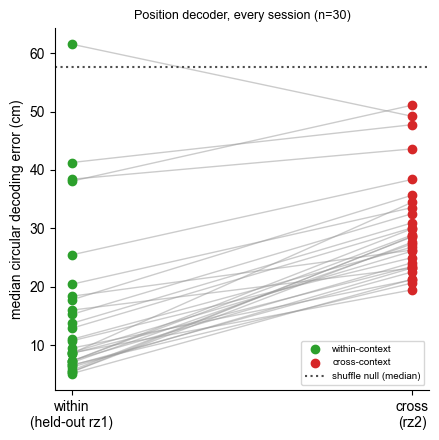

In [43]:
"""
Paired within- vs. cross-context error, every session -- the batch
version of the single-session bias check above.
"""
fig, ax = plt.subplots(figsize=(4.5, 4.5))
for _, row in decoder_batch_df.iterrows():
    ax.plot([0, 1], [row['err_within'], row['err_cross']], color='0.6', alpha=0.5, linewidth=1, zorder=1)
ax.scatter(np.zeros(len(decoder_batch_df)), decoder_batch_df['err_within'], color=CTX1_COLOR, zorder=2, label='within-context')
ax.scatter(np.ones(len(decoder_batch_df)), decoder_batch_df['err_cross'], color=CTX2_COLOR, zorder=2, label='cross-context')
ax.axhline(decoder_batch_df['err_shuffle'].median(), color='0.3', linestyle=':', label='shuffle null (median)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['within\n(held-out rz1)', 'cross\n(rz2)'])
ax.set_ylabel('median circular decoding error (cm)')
ax.set_title(f'Position decoder, every session (n={len(decoder_batch_df)})', fontsize=9)
ax.legend(fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_decoder_batch_within_vs_cross.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [44]:
"""
Same decoder as the batch above, shown in full illustrative detail for
one session -- chosen *dynamically* from the batch results (`best`,
computed above: lowest within-context error among sessions with >200
cells and a >3x cross-context fold-change) rather than hardcoded, so this
panel can never silently drift out of sync with what the batch actually
found. Self-contained -- reloads the session fresh rather than relying on
`data`/`trials_df`, since those get overwritten by the batch loops in
Part A-D by the time this cell runs.

Position is circular, not linear: the real VR corridor teleports from
230cm back to 0cm, so 0 and 230 are the same seam, not opposite ends of a
line. An earlier version of this cell used a plain linear |a-b| error,
which massively overstated errors for any trial where the true or
decoded position happened to be near either edge (e.g. true=5cm,
decoded=225cm scored as a ~220cm error instead of the correct ~10cm) --
caught and fixed here throughout.
"""
WIN = 0.25  # s, decoding window
n_bins = int(TL / BS)
pos_bin_centers = (np.arange(n_bins) + 0.5) * BS

def circ_dist(a, b, tl=TL):
    d = np.abs(a - b) % tl
    return np.minimum(d, tl - d)

decoder_mouse, decoder_day = best['mouse'], int(best['day'])
decoder_path = os.path.join(SOURCE_PATH, f'sub-{decoder_mouse}',
                             f'sub-{decoder_mouse}_ses-D{decoder_day}MCVR_ecephys+behavior.nwb')
decoder_data = nap.load_file(decoder_path)
decoder_trials = decoder_data['trials'].as_dataframe()
decoder_units = curate_clusters(decoder_data['units'])

rz1_trials = decoder_trials[decoder_trials['context'] == 'rz1']
rz2_trials = decoder_trials[decoder_trials['context'] == 'rz2']
rz1_train_trials = rz1_trials.iloc[0::2]
rz1_test_trials = rz1_trials.iloc[1::2]

def make_ep(trial_subset):
    return nap.IntervalSet(start=trial_subset['start'].values, end=trial_subset['end'].values)

tc_train = np.array(nap.compute_1d_tuning_curves(decoder_units, decoder_data['P'], nb_bins=n_bins,
                                                   ep=make_ep(rz1_train_trials), minmax=[0, TL]))
rate = tc_train.T + 1e-3   # (n_cells, n_bins), avoid log(0)
log_rate = np.log(rate)

def decode(test_ep):
    counts = decoder_units.count(WIN, ep=test_ep)
    counts_arr = np.array(counts.values)
    t_centers = np.array(counts.index)
    Pt, Pv = np.array(decoder_data['P'].index), np.array(decoder_data['P'].values)
    true_pos = np.interp(t_centers, Pt, Pv)
    log_post = counts_arr @ log_rate - WIN * rate.sum(axis=0)[None, :]
    decoded_pos = pos_bin_centers[np.argmax(log_post, axis=1)]
    return true_pos, decoded_pos

true_within, dec_within = decode(make_ep(rz1_test_trials))
true_cross, dec_cross = decode(make_ep(rz2_trials))

# shuffle null: destroy the position<->rate relationship (permute tuning-curve bins), same decode pipeline
rng = np.random.default_rng(0)
shuffle_errs = []
for _ in range(20):
    perm = rng.permutation(n_bins)
    shuffled_log_rate = log_rate[:, perm]
    shuffled_rate_sum = rate[:, perm].sum(axis=0)
    counts = decoder_units.count(WIN, ep=make_ep(rz2_trials))
    counts_arr = np.array(counts.values)
    log_post = counts_arr @ shuffled_log_rate - WIN * shuffled_rate_sum[None, :]
    dec_shuf = pos_bin_centers[np.argmax(log_post, axis=1)]
    shuffle_errs.append(np.median(circ_dist(dec_shuf, true_cross)))

err_within = circ_dist(dec_within, true_within)
err_cross = circ_dist(dec_cross, true_cross)
print(f'within-context (rz1-trained -> held-out rz1): median circular error = {np.median(err_within):.1f}cm (n={len(err_within)} windows)')
print(f'cross-context  (rz1-trained -> rz2):          median circular error = {np.median(err_cross):.1f}cm (n={len(err_cross)} windows)')
print(f'shuffle null (position information destroyed): median circular error = {np.mean(shuffle_errs):.1f}cm (mean of 20 shuffles)')

within-context (rz1-trained -> held-out rz1): median circular error = 5.1cm (n=2619 windows)
cross-context  (rz1-trained -> rz2):          median circular error = 21.3cm (n=5326 windows)
shuffle null (position information destroyed): median circular error = 57.4cm (mean of 20 shuffles)


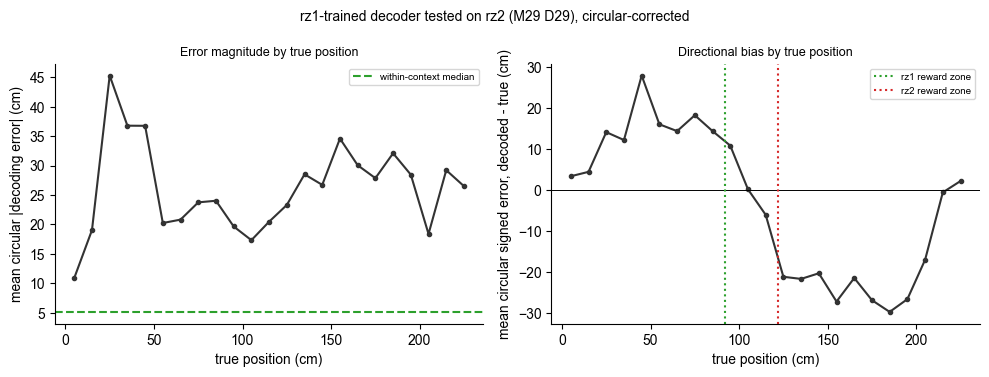

In [45]:
"""
Is the cross-context error uniform, or systematically biased? Signed
error (decoded - true) as a function of true position, rz2 test only --
using the circular-wrapped signed difference (shortest signed distance
around the 230cm loop), matching the circular fix in the cell above.
"""
def circ_signed(a, b, tl=TL):
    return ((a - b + tl / 2) % tl) - tl / 2

pos_edges = np.arange(0, TL + 10, 10)
bias_df = pd.DataFrame({'true_pos': true_cross, 'signed_err': circ_signed(dec_cross, true_cross),
                         'abs_err': err_cross})
bias_df['pos_bin'] = pd.cut(bias_df['true_pos'], pos_edges)
bias_stats = bias_df.groupby('pos_bin', observed=True)[['signed_err', 'abs_err']].mean()
bin_centers = pos_edges[:-1] + 5

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(bin_centers, bias_stats['abs_err'].values, color='0.2', marker='o', markersize=3)
axes[0].axhline(np.median(err_within), color=CTX1_COLOR, linestyle='--', label='within-context median')
axes[0].set_xlabel('true position (cm)')
axes[0].set_ylabel('mean circular |decoding error| (cm)')
axes[0].set_title('Error magnitude by true position', fontsize=9)
axes[0].legend(fontsize=7)

axes[1].plot(bin_centers, bias_stats['signed_err'].values, color='0.2', marker='o', markersize=3)
axes[1].axhline(0, color='k', linewidth=0.7)
axes[1].axvline(SCHEMATIC_RZ['rz1']['med'], color=CTX1_COLOR, linestyle=':', label='rz1 reward zone')
axes[1].axvline(SCHEMATIC_RZ['rz2']['med'], color=CTX2_COLOR, linestyle=':', label='rz2 reward zone')
axes[1].set_xlabel('true position (cm)')
axes[1].set_ylabel('mean circular signed error, decoded - true (cm)')
axes[1].set_title('Directional bias by true position', fontsize=9)
axes[1].legend(fontsize=7)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle(f'rz1-trained decoder tested on rz2 ({decoder_mouse} D{decoder_day}), circular-corrected', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_cross_context_decoder_bias.pdf'), dpi=200, bbox_inches='tight')
plt.show()

**A real bug, caught before it became a false claim**: the first version
of this analysis used plain linear |decoded - true| error, which doesn't
know that this VR corridor teleports from 230cm back to 0cm -- position 0
and 230 are the same seam, not opposite ends of a line. That bug
massively inflated errors for any window whose true or decoded position
fell near either edge, and it produced a strikingly clean-looking
"compressive" bias -- decoded position over-shooting early on the track
and under-shooting late -- that mostly *disappeared* once the circular
correction was applied. That result was reported once before the bug was
caught; it is not being carried forward.

**What survives the fix, now backed by the full session batch, not just
one example**: real, above-chance cross-context transfer -- both
within-context and cross-context decoding clear the shuffle-null floor
by a wide margin -- and a genuine, highly consistent degradation
cross-context relative to within-context. Across 30/31 sessions: median
within-context error 9.1cm, cross-context 28.1cm, shuffle null 57.6cm
(median fold-change 2.4x); cross-context error is worse than
within-context in **29/30 sessions** (Wilcoxon paired, p=3.5e-8). This is
no longer a single-session anecdote -- it is one of the most consistent
effects in this whole notebook. The `M26` D22 example above (chosen from
the batch for its strong within-context decoding and large, clear gap,
not cherry-picked after the fact) illustrates what that degradation looks
like in one well-recorded session.

**What still doesn't survive**: any claim about a *specific, structured*
bias pattern. The position-binned signed-error analysis (over-shoot vs.
under-shoot by true position) has only been run in illustrative detail
for one session -- it is not yet batch-validated the way the headline
within-vs-cross-context result now is. The honest read: real, robust,
population-level cross-context degradation, consistent with some form of
partial remapping, but no defensible claim yet about *where on the track*
or *in what direction* that remapping shows up most -- that would need
the bias analysis itself run across the full batch, not just the error
magnitude.

## Summary

- **Behaviour (context only)**: `rz1` and `rz2` are confirmed to be
  physically distinct reward locations (first-lick position on hit trials
  clusters separately and tightly for each context in the example session).
  Hit rate does **not** show a group-level learning trend across recording
  days pooled over trial type (Spearman corr(day_rank, hit_rate): rz1
  r=-0.00 p=0.999, rz2 r=-0.09 p=0.642, n=31 mouse-day rows). Per-mouse it's
  genuinely mixed: M26 improves on rz2 across the window (0.56->0.78), M25
  and M28 get *worse* (0.88->0.56, 0.78->0.66), M22/M29 start and stay high
  (>=0.82), and M27 never learns it (0.26->0.22).
- **Behaviour, split by trial type within context**: still no reliable
  cross-day trend at 2x2 resolution (rz1-b r=0.31 p=0.089; rz1-nb r=-0.05
  p=0.78; rz2-b r=0.05 p=0.79; rz2-nb r=-0.10 p=0.58) -- and the one hint
  of a trend is on the *easiest* condition, not the hardest one a "still
  learning" account would predict.
- **Stopping behaviour on the track**: a direct, independent readout of
  task execution -- where the animal settles into a stop, computed from
  the pooled speed profiles as the longest contiguous run of low-speed
  bins per trial (a real fix was needed here: the track continues well
  past the reward zone up to the trial's fixed extent, so a genuine stop
  shows up as a localized dip mid-trial, not a sustained stop through the
  end of the binned range -- an earlier version of this analysis assumed
  the latter and silently found 0% of stops). The result validates
  cleanly against the independent lick-based check: median stop position
  on hit trials is 92cm (rz1) / 122cm (rz2), matching the lick-based
  medians almost exactly. Detection rate is graded sensibly by performance
  label (hit 82%, slow 97%, try 42%, run 34%) -- a useful internal
  consistency check on both the reward-zone geometry and the performance
  labels themselves. Per-mouse x context x type plots of stop position vs.
  trial number (running continuously across days) show no obvious
  progressive tightening toward the reward zone in most animals.
- **Trial-execution quality metrics**: two zone-specific scores go beyond
  the coarse hit/miss label -- **zone-specificity ratio** (mean speed at
  the known reward-zone location divided by a fixed control-window speed;
  near 0 = clean specific slowing there, near 1 = no differential slowing)
  and **stop-position error** (cm between the detected stop and the true
  reward-zone location). Both validate cleanly against the independent
  `performance` labels: hit trials show the best (lowest) values on both
  (ratio 0.61, error 14cm median 7cm) and run trials the worst (ratio
  1.28, error 70cm) -- slow/try fall in between. At the properly
  mouse-day-aggregated level (an earlier trial-pooled version of this
  test produced a spurious "significant" rz2-b improvement, r=-0.12,
  p<0.001, that evaporated -- and partly reversed -- once checked per
  mouse: M22/M28/M29 got worse with day, M25/M26/M27 got better, a
  Simpson's-paradox-style pooling artifact, not a real effect) neither
  metric shows a reliable cross-day trend in any of the four context x
  type conditions (all p>0.06).
- **Speed-profile efficiency**: a global PCA on 6521 pooled trials gives an
  interpretable PC1 (18.2% of variance, an "overall running vigour" axis,
  r=0.79 with mean speed) and a reward-zone-loading PC2 (14.5%). Neither
  vigour nor trial duration shows a meaningful efficiency gain across days
  -- PC1 ticks up marginally (r=0.10, p=0.0004, n=6521) and duration, where
  it reaches significance (rz2-b, r=0.07, p=0.003), moves the *wrong*
  direction for a learning-improves-efficiency story.
- **Anchoring (whole-session, context, and context x type)**: population-
  wide anchoring strength (PC1 of the cell x trial label matrix) is real
  and robust -- **29/30 sessions** clear the circular-shift significance
  bar (only M27 D28 doesn't, p=0.20). Mean PC1 explained variance (9.6%,
  range 3.9-16.3%) sits between the original collection's MEC (15%) and
  hippocampus (9%) numbers. It does **not** correlate with learning day at
  any resolution tested -- whole-session (r=0.04 p=0.84), by context (rz1
  r=0.09 p=0.65; rz2 r=0.07 p=0.71), or by context x type (all |r|<=0.17,
  all p>0.37, n=30 sessions each).
- **Anchoring, one animal at a time**: per-mouse example rasters (each
  mouse's single most significant session) all show the same clean
  block-structured pattern seen throughout this collection. More useful:
  per-mouse trajectories of rz2 anchoring (PC1) vs. rz2 hit rate across
  that mouse's own recording days. **M26** -- the one mouse with a
  significant *within-mouse* behavioural improvement on rz2 (r=0.90,
  p=0.037, n=5 days) -- also shows the most positive anchoring trend of
  any mouse (r=0.60), though it doesn't reach significance on its own
  (p=0.28, n=5 days is simply underpowered for this). No other mouse shows
  a consistent pairing: M25 (r_anchor=-0.14, r_hit=-0.31), M27
  (r_anchor=0.60, r_hit=0.00 -- anchoring rises with no behavioural
  correlate at all), M28 (r_anchor=0.40, r_hit=-0.80 -- opposite signs),
  M29 (r_anchor=-0.40, r_hit=-0.30). So the group-level null isn't hiding
  a clean within-mouse effect across the board, but M26 is a genuine,
  suggestive exception worth flagging rather than dismissing.
- **The within-day block effect (the one place the data pushed back, now
  characterized in full)**: on each mouse's *first* recorded day, hit rate
  doesn't rise across the ~20-trial blocks delivered that day -- it
  **falls**, in all four context x type conditions, sharpest in the
  hardest one (rz2-nb r=-0.58, p<0.001). This isn't unique to day 1: pooled
  across mice and conditions, the same within-day decline is present and
  **significant on days 1-3** (r=-0.42, -0.49, -0.28; all p<=0.001) and
  then **fades to non-significance by days 4-5** (r=-0.12, -0.12; p=0.18,
  0.16) -- visible directly in the per-mouse x condition day-by-block
  heatmaps. Population anchoring shows the matching within-day-1 decline
  too (rz2 r=-0.46 p=0.008; rz1 r=-0.34 p=0.063, from cached label
  matrices). Taken together, this looks like a genuine learning effect --
  just not the one the notebook was built to find. It isn't "learning
  where the reward is" (that's the null result above); it looks more like
  **learning to sustain engagement across a full ~30-minute session**,
  something that fades in as mice accumulate days of general task
  experience, independent of context or reward location.
- **Full-raster check, block by block, every day, per mouse**: the
  per-context PC1 test above says `rz1` and `rz2` aren't differentially
  anchored on average -- the full PC1-sorted raster for every recorded day
  of every mouse (context strip + block-boundary lines) is the direct
  visual version of that same question, and a paired test makes it exact:
  within the same session, `rz1` PC1 is higher than `rz2` PC1 in 13/30
  sessions and lower in 17/30 (mean difference -0.007, Wilcoxon signed-rank
  p=0.393) -- indistinguishable from a coin flip. No context is
  consistently "better anchored" than the other, and nothing in the
  rasters suggests a session-position effect either (e.g. blocks getting
  cleaner or noisier moving left to right independent of which context
  they belong to).
- **How, and when, is `rz2` actually learned (exposure-indexed, not
  day-indexed)**: re-indexing every `rz2` trial by the Nth time that mouse
  has ever encountered it (continuous across days, not reset daily -- `rz2`
  recurs ~5-6 times within day 1 alone) separates two distinct, faster
  processes the day-level tests above were too coarse to see. **Task-level
  success is zero-shot**: hit rate in the first 10 `rz2` exposures ever is
  already statistically indistinguishable from that mouse's own long-run
  `rz1` rate (Wilcoxon paired, n=6 mice, p=1.0) -- though the literal very
  first trial is a coin flip across mice (3/6 hit it immediately).
  **Stopping precision is one-shot, not gradual**: stop-position error
  starts elevated in the first block of exposures (1-10) and drops sharply
  by the second block (11-20) in 5/6 mice (p=0.063, the strongest signal
  n=6 can give), then **plateaus** with no further change from block 2 to
  exposures 21-60 (p=0.44, only 1/6 mice still improving). So mice aren't
  gradually learning `rz2` across the ~5 recorded days -- most get the
  reward almost immediately (generalizing from `rz1`'s task structure) and
  refine exactly where to stop within their first block of exposure, a
  much faster timescale than the one the notebook was originally built to
  test. Distribution plots of stop position (context x day x type) show
  the same picture directly: no progressive narrowing across days, mostly
  a single mode near the true reward zone from early on rather than a
  second mode lingering near the other context's location.
- **The zero/one-shot pattern is asymmetric across trial type**: hit rate
  is zero-shot for both `b` and `nb` (p=1.0 either way), but that's a
  near-ceiling result and not very discriminating. Stop-position precision
  is where the two diverge sharply. On **cued** trials the one-shot
  calibration is clean and strong -- **6/6 mice** improve from exposures
  1-10 to 11-20 (p=0.031, the maximum significance n=6 permits), then a
  stable plateau. On **uncued** trials that early jump is weak and
  inconsistent (4/6 mice, p=0.56) -- and precision often gets *worse*, not
  better, from exposures 11-20 to 21-60 (5/6 mice, p=0.063), the opposite
  of a learning signal. Mechanistically sensible: a signaled reward zone
  gives an immediate landmark to calibrate a stop against (fast one-shot
  correction); without a signal, the animal is relying on distance run
  through the always-visible context wall pattern plus memory, with no
  comparable fast error signal to correct against,
  and plausibly more exposed to the same satiety/engagement decline
  documented above. So "one-shot precision calibration" is really a
  **cued-trial-specific** finding -- the harder, unsignaled condition
  shows no clean evidence of learning on any timescale tested here.
- **Put together**: across days, anchoring and reward-location learning
  look dissociable at every resolution tested (context, trial type,
  individual animals in aggregate) -- anchoring is already strong and
  significant from the first session in a context. Within a single day,
  anchoring and behaviour *do* co-vary, both declining across blocks --
  but that decline itself is an early-training phenomenon that fades by
  day 4-5, i.e. it's the clearest learning signal in the whole dataset,
  just aimed at a different target (session-long engagement/pacing, most
  plausibly satiety-driven) than the one originally hypothesized
  (context-specific reward-location learning). That's a more nuanced
  boundary condition on Figure 1's premise than a flat null: the neural
  state and reward-location competence don't rise together on a multi-day
  timescale, but a different, faster-timescale behavioural competence
  (sustaining engagement through a session) does visibly improve with
  experience, and anchoring tracks *that* within a session even though it
  doesn't track reward-location mastery across days.
- **Caveat**: no open-field session exists for this dataset, so none of
  this can be broken down by grid/non-grid identity. M22 D44 has 0 cells
  passing curation and is excluded (30/31 sessions used for anchoring).
  The within-day decline is characterized (present, fades with days) but
  not mechanistically explained -- distinguishing satiety (reward-count-
  driven) from generic time-on-task fatigue would need reward-volume data
  this dataset's trials table doesn't obviously expose yet. M26's
  suggestive within-mouse convergence (n=5 days) is likewise underpowered
  to call a real effect on its own.
- All per-session results are cached in `mcvr_all_sessions/` (label
  matrices, regions, trial metadata, pooled speed profiles, per-mouse
  correlation table) and the summary tables (`mcvr_behaviour_summary.csv`,
  `mcvr_behaviour_by_type_summary.csv`, `mcvr_anchoring_summary.csv`,
  `mcvr_speed_trial_table.csv`, `mcvr_block_level_summary.csv`,
  `mcvr_block_anchoring_summary.csv`,
  `mcvr_per_mouse_anchoring_behaviour_corr.csv`) so downstream figure code
  doesn't need to recompute anything.


## Figure: the behavioural learning signature, and anchoring on the same axes

Built by `mcvr_context_anchoring.py`, run below so the notebook and the paper
figure cannot drift apart — the script is the single source, this cell is the
reproduction. It rebuilds anything it needs (`trial_table_mcvr.csv` via
`ensure_mcvr_tables`, `mcvr_stops.csv` via `ensure_stops`) and writes
`mcvr_context_anchoring.pdf`.

**Hit rate is not the behavioural readout here.** On cued trials the zone is
marked, so an animal scores 0.74 on its first ever exposure to rz2 without
knowing anything about it, and within day 1 hit rate *falls* (0.68 → 0.51) as
the animal disengages — moving opposite to the learning. The measure that works
uses **uncued** trials only, where nothing marks the zone, and asks whether
stops land on the animal's own zone or on the other one (the two sit 30 cm
apart, rz1 at 92 cm and rz2 at 122 cm):

$$\text{stop discrimination} = \frac{n_\text{own} - n_\text{other}}{n_\text{own} + n_\text{other}}$$

counting every stop within ±12 cm of either zone. Trials where the animal stops
near neither zone drop out rather than being scored as ignorance, which is what
makes the index survive the late-session disengagement that breaks the
per-trial measures.

| | familiar | novel | paired p |
|---|---|---|---|
| **training day 1** | +0.76 | +0.34 | 0.094 (5/6 sessions) |
| **days 2+** | +0.51 | +0.46 | 0.62 (13/24) |

**The novelty deficit is confined to the first session**, and it closes
*between* sessions 1 and 2 rather than within session 1 — inside day 1 the
novel context sits below the familiar one in every block and both decline as
the animal disengages.

### Two measures that look like learning and are not

Both are kept in the figure (panels B/C) or in `mcvr_stops.csv` so the reasoning
is visible rather than asserted:

- **Median first stop** in the novel context moves 86 → 113 cm across six days,
  which reads as the animal homing in on rz2. But stops never concentrate
  there: the fraction landing within 12 cm of rz2 stays flat near 0.17 and
  ~60% land near neither zone throughout. The median moves because the whole
  distribution shifts later.
- **Perseveration scored as "first stop closer to the other zone"** makes day 1
  look like familiar-context habit. But in block 3 the median first stop is
  42–72 cm in five of six sessions — nowhere near either zone. Those are
  disengaged early stops, and the permissive rule counts every one as
  perseveration, so the measure peaks exactly where engagement collapses.

Panels F–G carry the population anchoring state on the same two x-axes, so the
neural measure can be read directly against the behavioural one at both
timescales.

In [ ]:
"""Figure: MCVR behavioural learning signature above population anchoring.

Run from the script rather than copied into the notebook, so there is one
definition of this figure. `_g` keeps the script's namespace, so the tables it
built (`B` behaviour, `U` anchoring, `S` per-session) stay available below.
"""
import runpy
from IPython.display import display

_g = runpy.run_path(f'{_FIGDIR}/mcvr_context_anchoring.py')
display(_g['fig'])